In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from h5 import HDFArchive
from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

Starting serial run at: 2026-09-06 19:30:01.803847


tp : -0.2, mu : [-0.8517850759228668, -0.6716672852022249, -0.46057022123212055], n = [np.float64(0.8), np.float64(0.8999999999998523), np.float64(1.0000000000000262)]
tp : 0.0, mu : [-0.43826440547706147, -0.19845687535815118, 3.907985046680551e-14], n = [np.float64(0.7999999999999953), np.float64(0.8999999999999952), np.float64(1.0000000000000207)]
tp : 0.2, mu : [-0.11835108272199893, 0.19757301236606614, 0.4605702212320972], n = [np.float64(0.8000000000001253), np.float64(0.9000000000000007), np.float64(0.9999999999999641)]


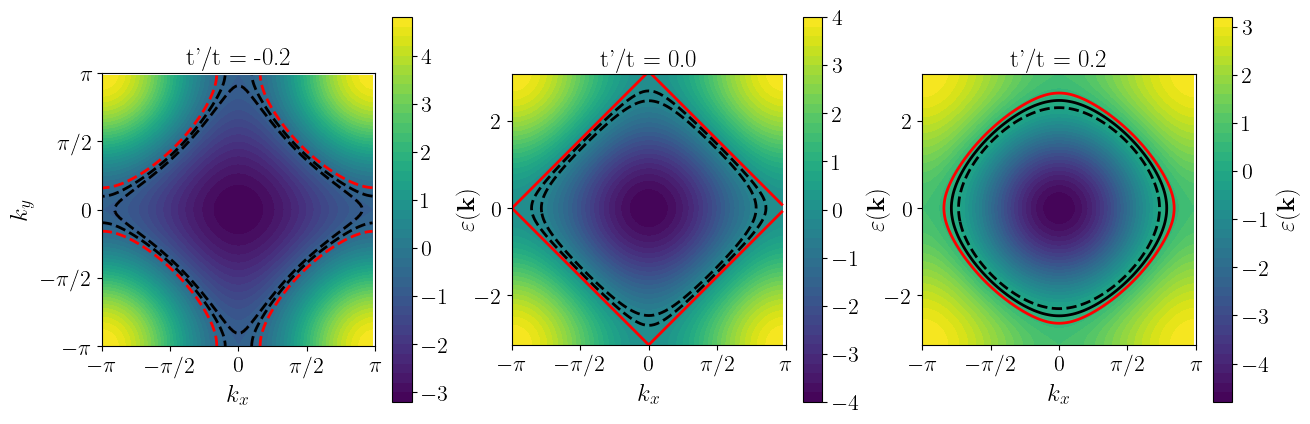

In [116]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

tp_list = [-0.2, 0., 0.2]
for i, tp in enumerate([-0.2, 0., 0.2]):

    lat = LATTICE(dim=2, tp=tp)
    nk = 100

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.1
    n_list = [0.8, 0.9, 1.]
    mu_list = [get_mu(e_k=lat.e_k, n_goal=n, beta=1/T) for n in n_list]
    n_check = [2*np.mean(1/(np.exp((lat.e_k-mu)/T)+1)) for mu in mu_list]

    cf = axs[i].contourf(kx, ky, e_k, levels=50)
    plt.colorbar(cf, ax=axs[i], label=r'$\varepsilon(\mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=mu_list[:-1], colors='black', linewidths=2)
    axs[i].contour(kx, ky, e_k, levels=[mu_list[-1]], colors='red', linewidths=2)
    print(f'tp : {tp}, mu : {mu_list}, n = {n_check}')

    axs[i].set_title(f"t'/t = {tp}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

<unknown>:41: SyntaxWarning: invalid escape sequence '\p'
<unknown>:41: SyntaxWarning: invalid escape sequence '\p'


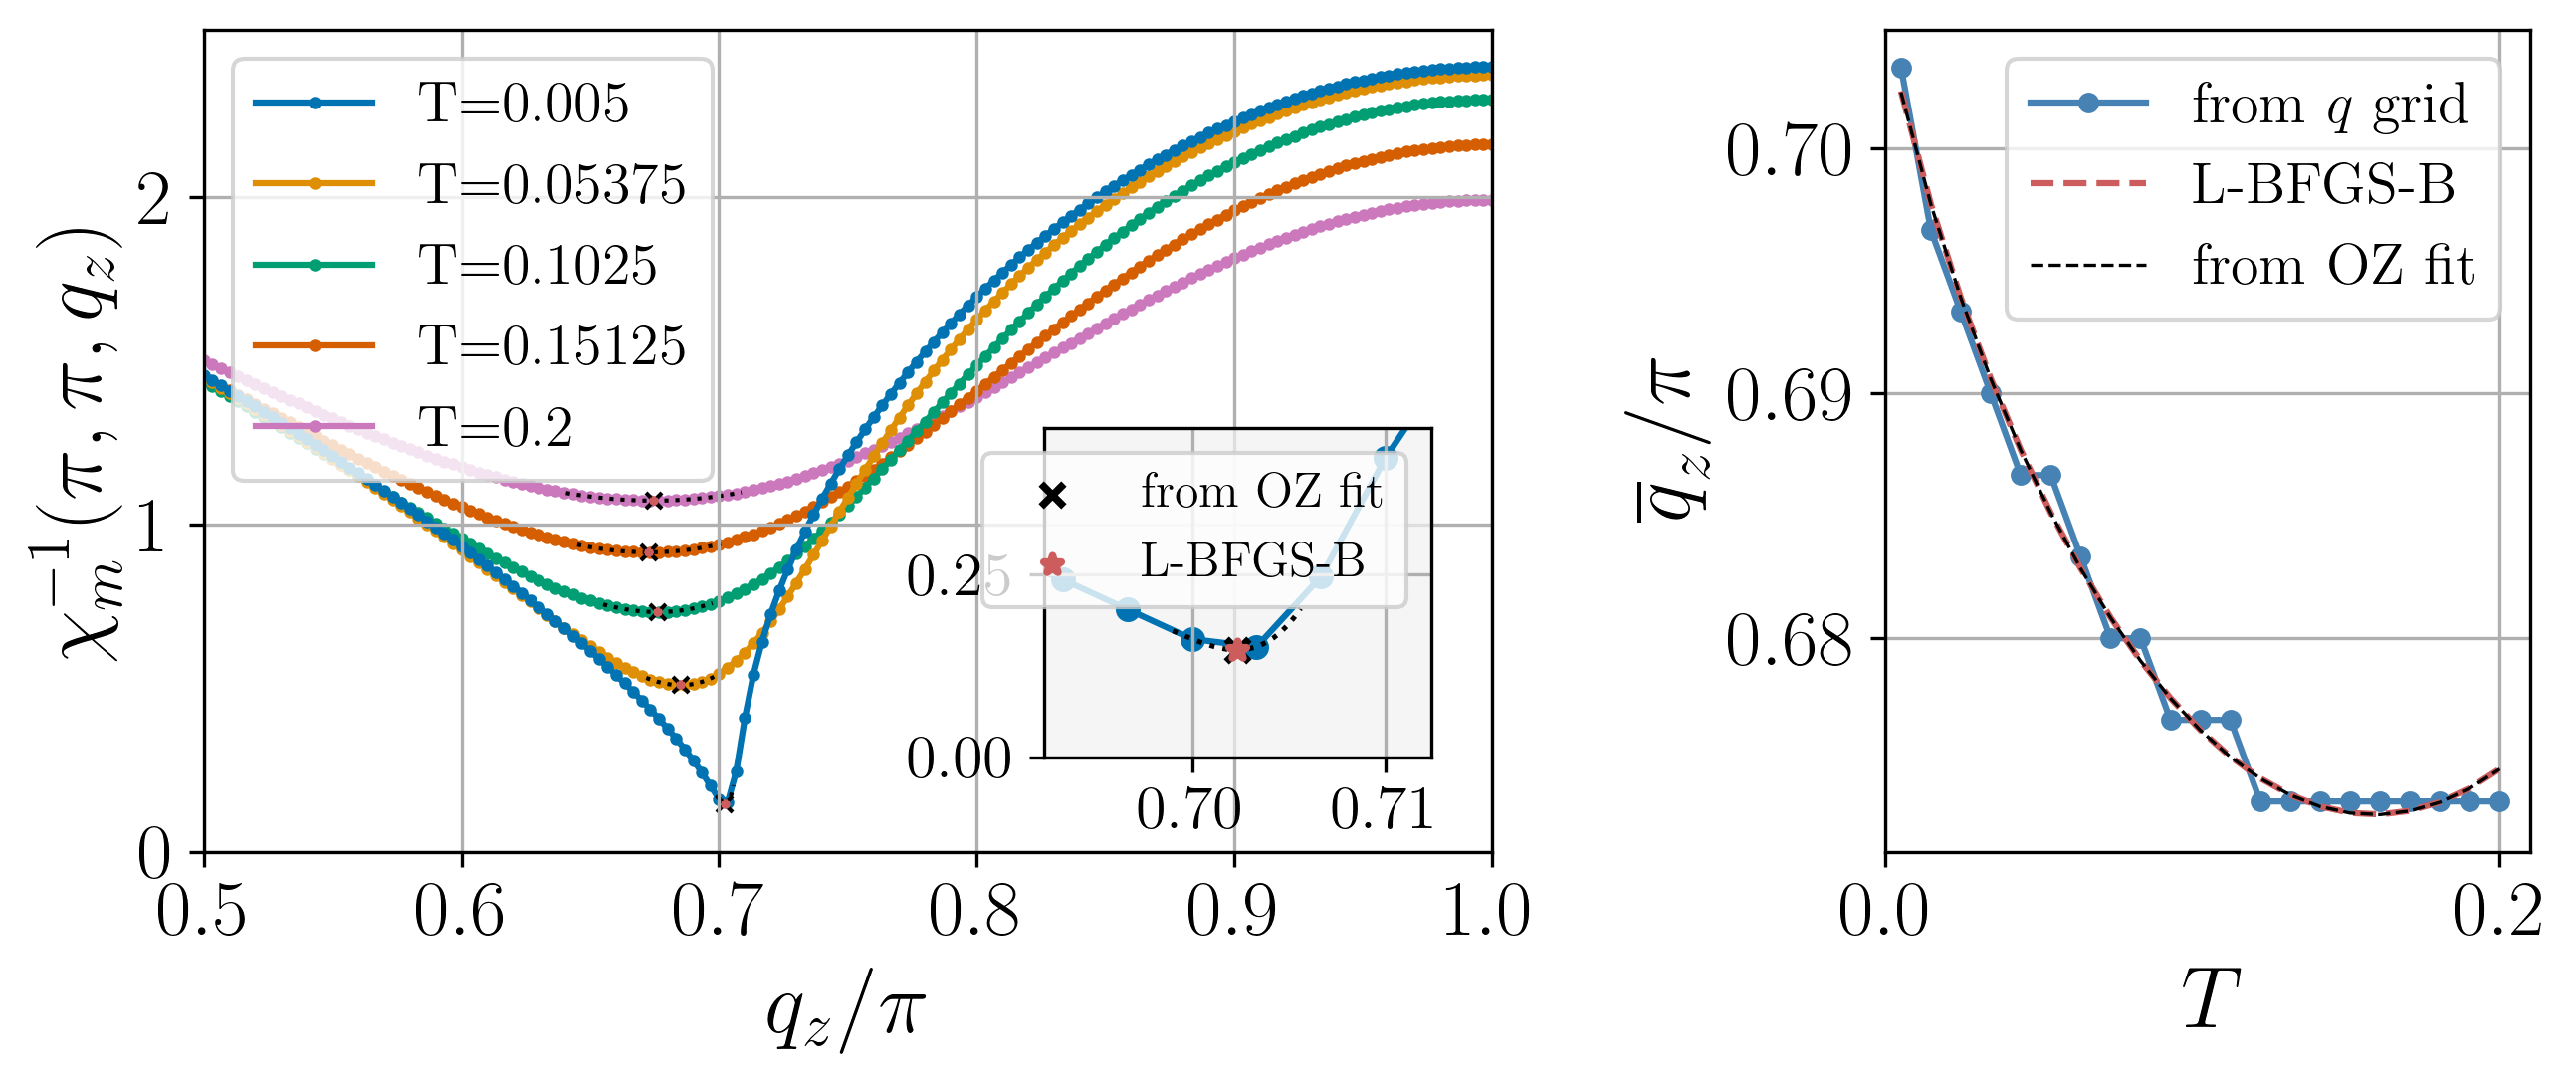

In [ ]:
n = 0.745
U = 3

with HDFArchive(f"data/chimin/G0tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data, peak_on_the='left', figsize=(9, 4), bigger_labels=3, plot_every=5)
plt.show()

[[ 6.27341126e+01 -1.07086356e+03  1.25953510e-02  7.94505725e-01]
 [ 2.38472206e+01 -1.98994303e+02  3.88367261e-02  7.97959877e-01]
 [ 1.44012919e+01 -7.96523634e+01  6.45479828e-02  8.01805465e-01]
 [ 1.01497039e+01 -3.94961505e+01  8.92457554e-02  8.05573192e-01]
 [ 7.84202972e+00 -2.20055832e+01  1.13143834e-01  8.09091588e-01]
 [ 6.44559409e+00 -1.31004580e+01  1.36579944e-01  8.12284749e-01]
 [ 5.51946735e+00 -8.12909181e+00  1.59772124e-01  8.15147151e-01]
 [ 4.84661566e+00 -5.23392293e+00  1.82768131e-01  8.17740729e-01]
 [ 4.31594356e+00 -3.53159228e+00  2.05487713e-01  8.20168926e-01]
 [ 3.87219022e+00 -2.54663535e+00  2.27785241e-01  8.22547127e-01]
 [ 3.48115118e+00 -1.97520811e+00  2.49510716e-01  8.24989156e-01]
 [ 3.13045642e+00 -1.66464534e+00  2.70519085e-01  8.27593044e-01]
 [ 2.81136081e+00 -1.50967106e+00  2.90696391e-01  8.30447161e-01]
 [ 2.51829205e+00 -1.44506190e+00  3.09959227e-01  8.33630985e-01]
 [ 2.24744215e+00 -1.43032181e+00  3.28252456e-01  8.37218422e

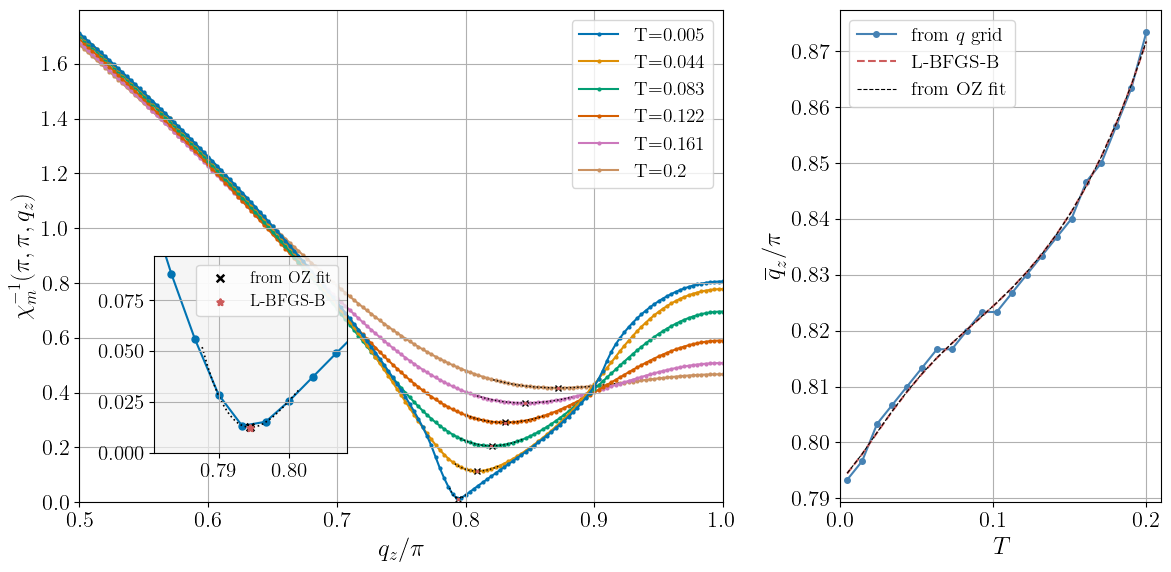

In [22]:
n = 0.8485
U = 3
tp = 0.1

with HDFArchive(f"data/chimin/G0tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

print(data['OZ_fit'], data['xi_range'])
plot_chimin(data, peak_on_the='right')
plt.show()

[[ 3.77473827e+00  8.82561485e-08  3.47064194e-04  1.00000000e+00]
 [ 4.25087190e+00 -6.98297836e-07  2.08069505e-03  1.00000000e+00]
 [ 4.36730004e+00 -1.83302415e-07  6.01792839e-03  1.00000000e+00]
 [ 3.80571053e+00  7.08587139e-07  1.11557972e-02  1.00000000e+00]
 [ 3.08185043e+00 -2.54219290e-06  1.61304934e-02  1.00000000e+00]
 [ 2.44904305e+00 -6.17140172e-07  2.02325966e-02  1.00000000e+00]
 [ 1.95595146e+00 -8.72289213e-07  2.32807323e-02  1.00000000e+00]
 [ 1.58952123e+00  9.88769887e-08  2.53965656e-02  1.00000000e+00]
 [ 1.32497174e+00 -3.13924476e-07  2.68671999e-02  1.00000000e+00]
 [ 1.13879227e+00 -1.28593212e-07  2.80549591e-02  1.00000000e+00]
 [ 1.01124537e+00  8.29166350e-08  2.93340826e-02  1.00000000e+00]
 [ 9.26450724e-01 -1.45771285e-08  3.10489470e-02  1.00000000e+00]
 [ 8.72027578e-01 -3.05000387e-08  3.34904482e-02  1.00000000e+00]
 [ 8.38617720e-01 -2.01380027e-08  3.68866356e-02  1.00000000e+00]
 [ 8.19335074e-01  5.85387872e-10  4.14033049e-02  1.00000000e

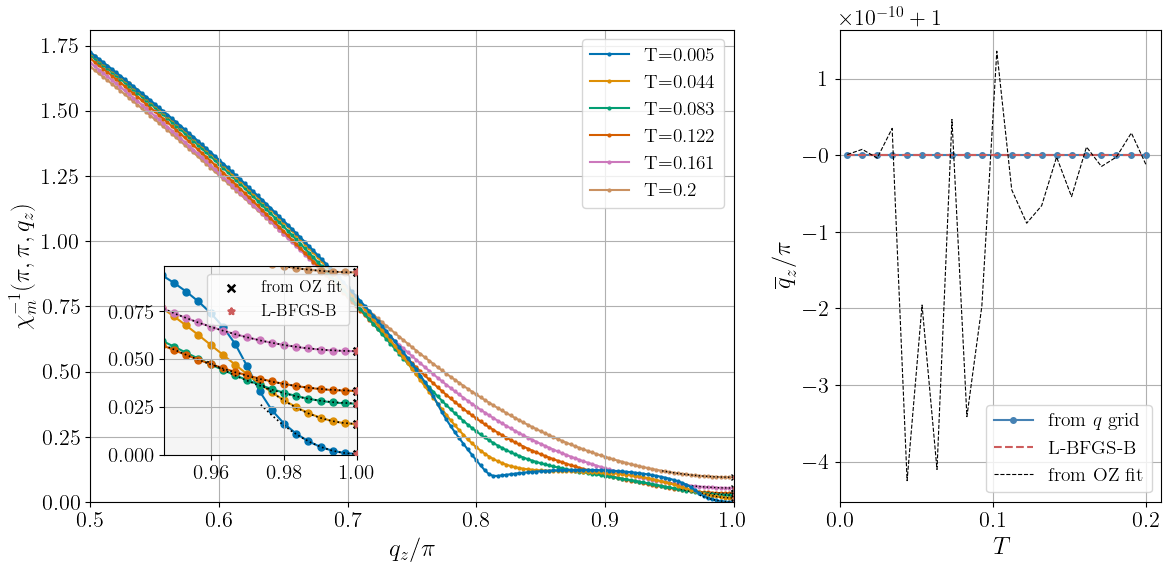

In [23]:
n = 0.88493
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/chimin/G0tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}
    
print(data['OZ_fit'], data['xi_range'])
plot_chimin(data, peak_on_the='right')
plt.show()

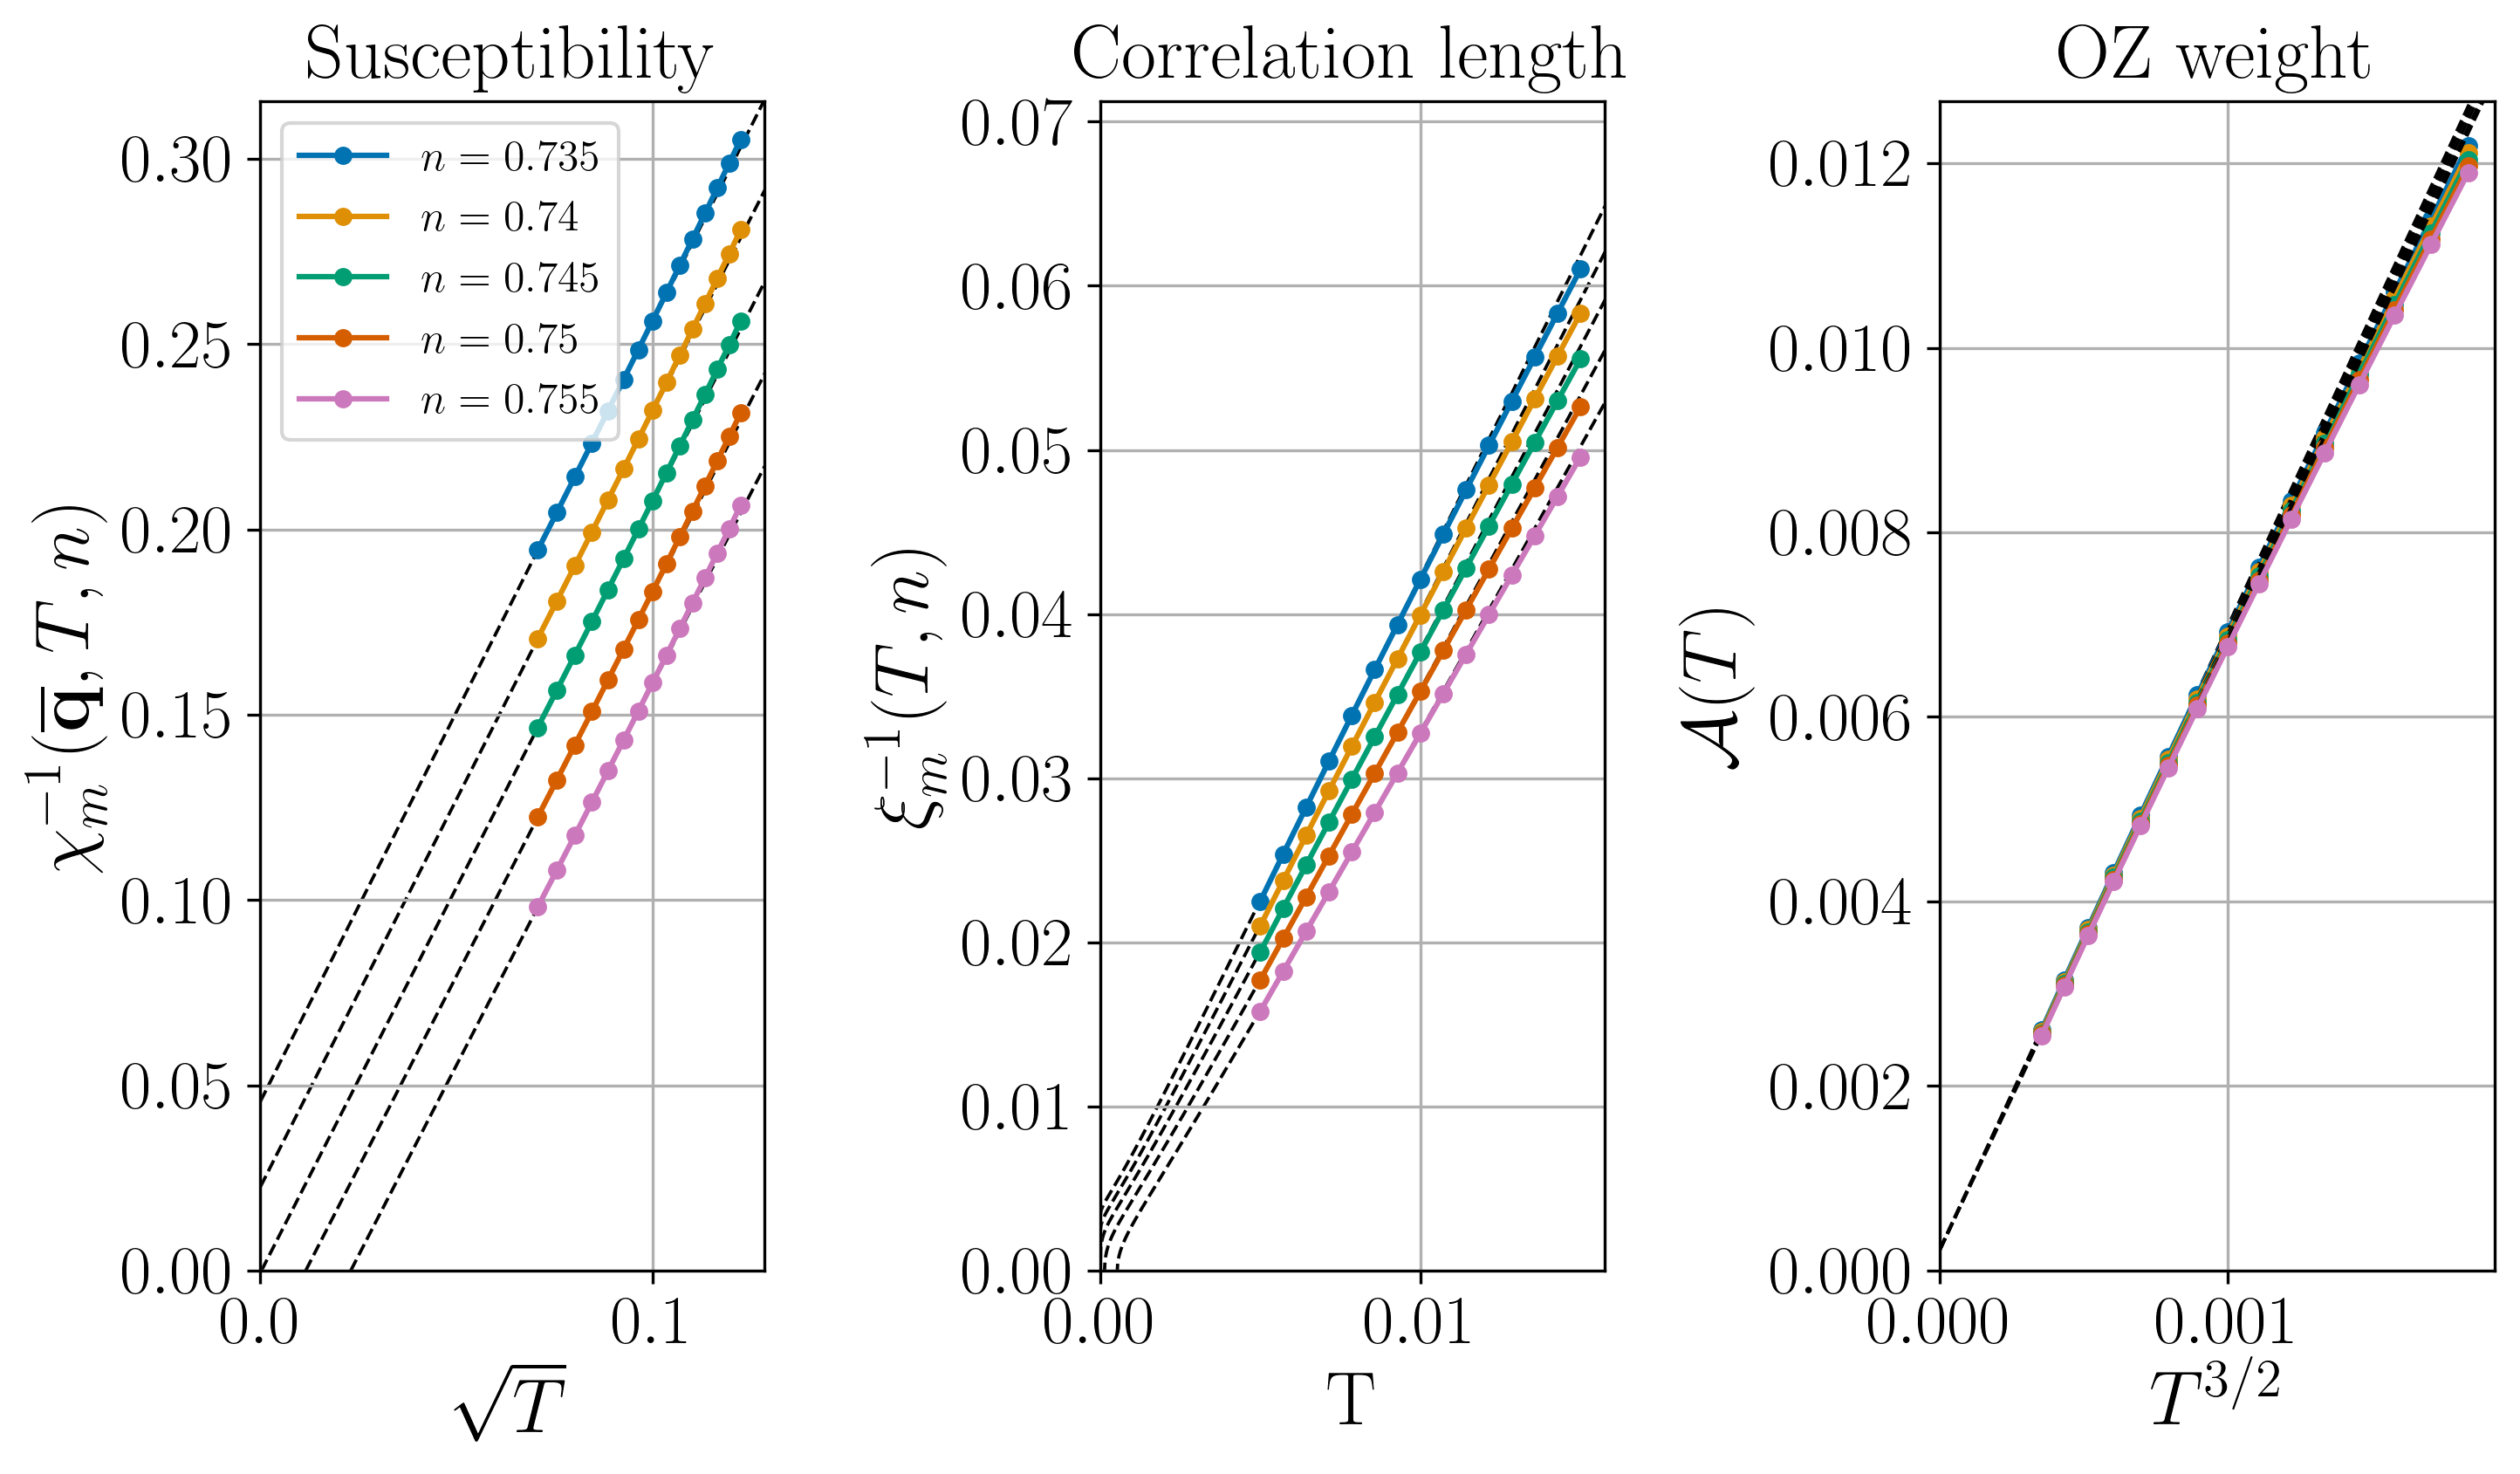

In [6]:
U = 3
tp = 0.

data = {}
with HDFArchive(f"data/scaling/tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(0.5, 1., 1.5), fit=True, right='OZ', figsize=(10, 6), bigger_labels=3)
plt.show()

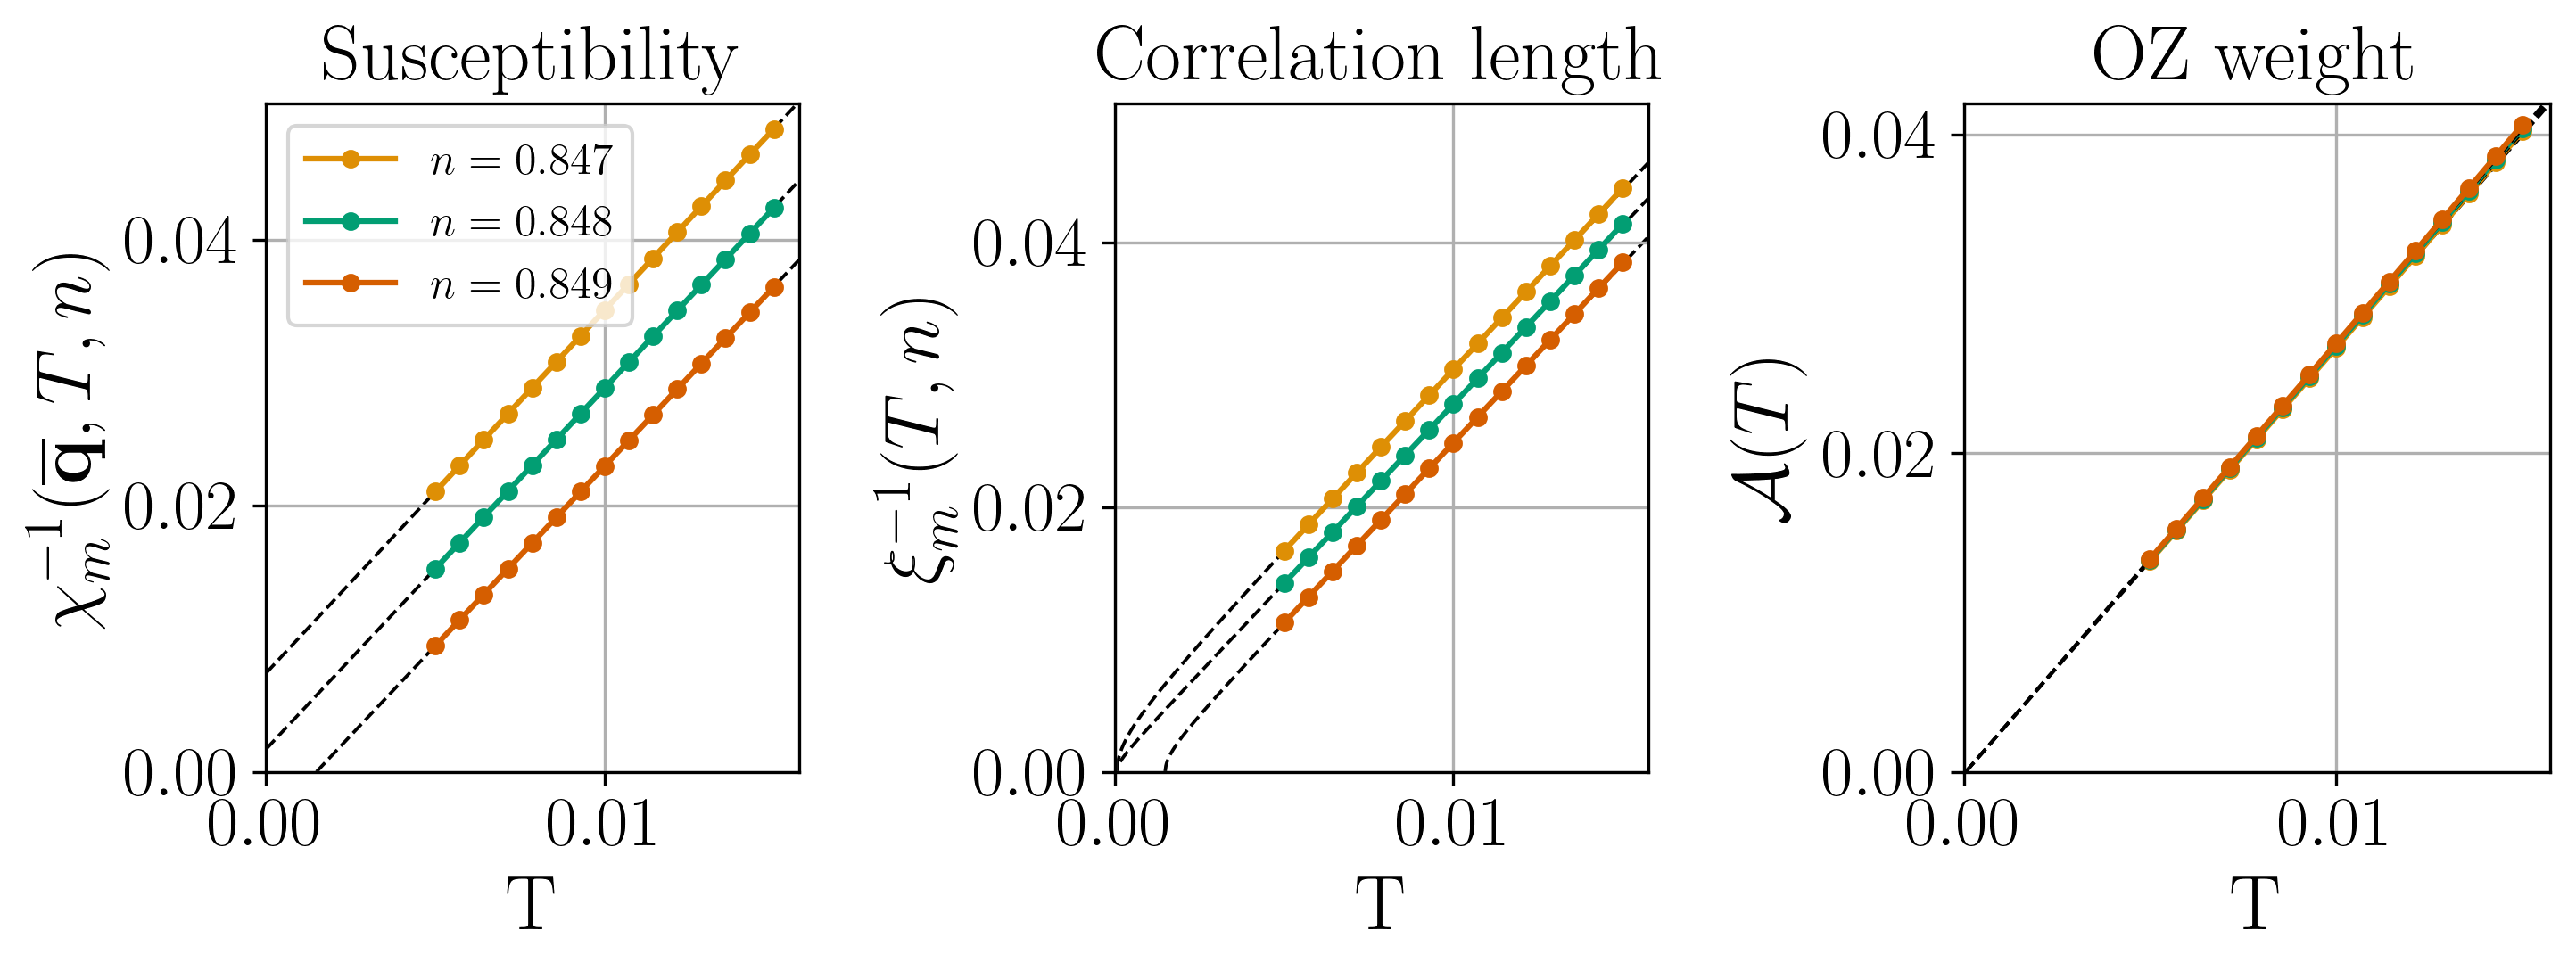

In [5]:
U = 3
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

data['n'] = data['n'][1:-1]
for k in ['invchi_min', 'invxi_min', 'OZ_weight']:
    data[k] = data[k][1:-1,:]
    
plot_scaling(data, x_exp=(1, 1, 1), fit=True, right='OZ', figsize=(10, 4), c0=1, bigger_labels=3)
plt.show()

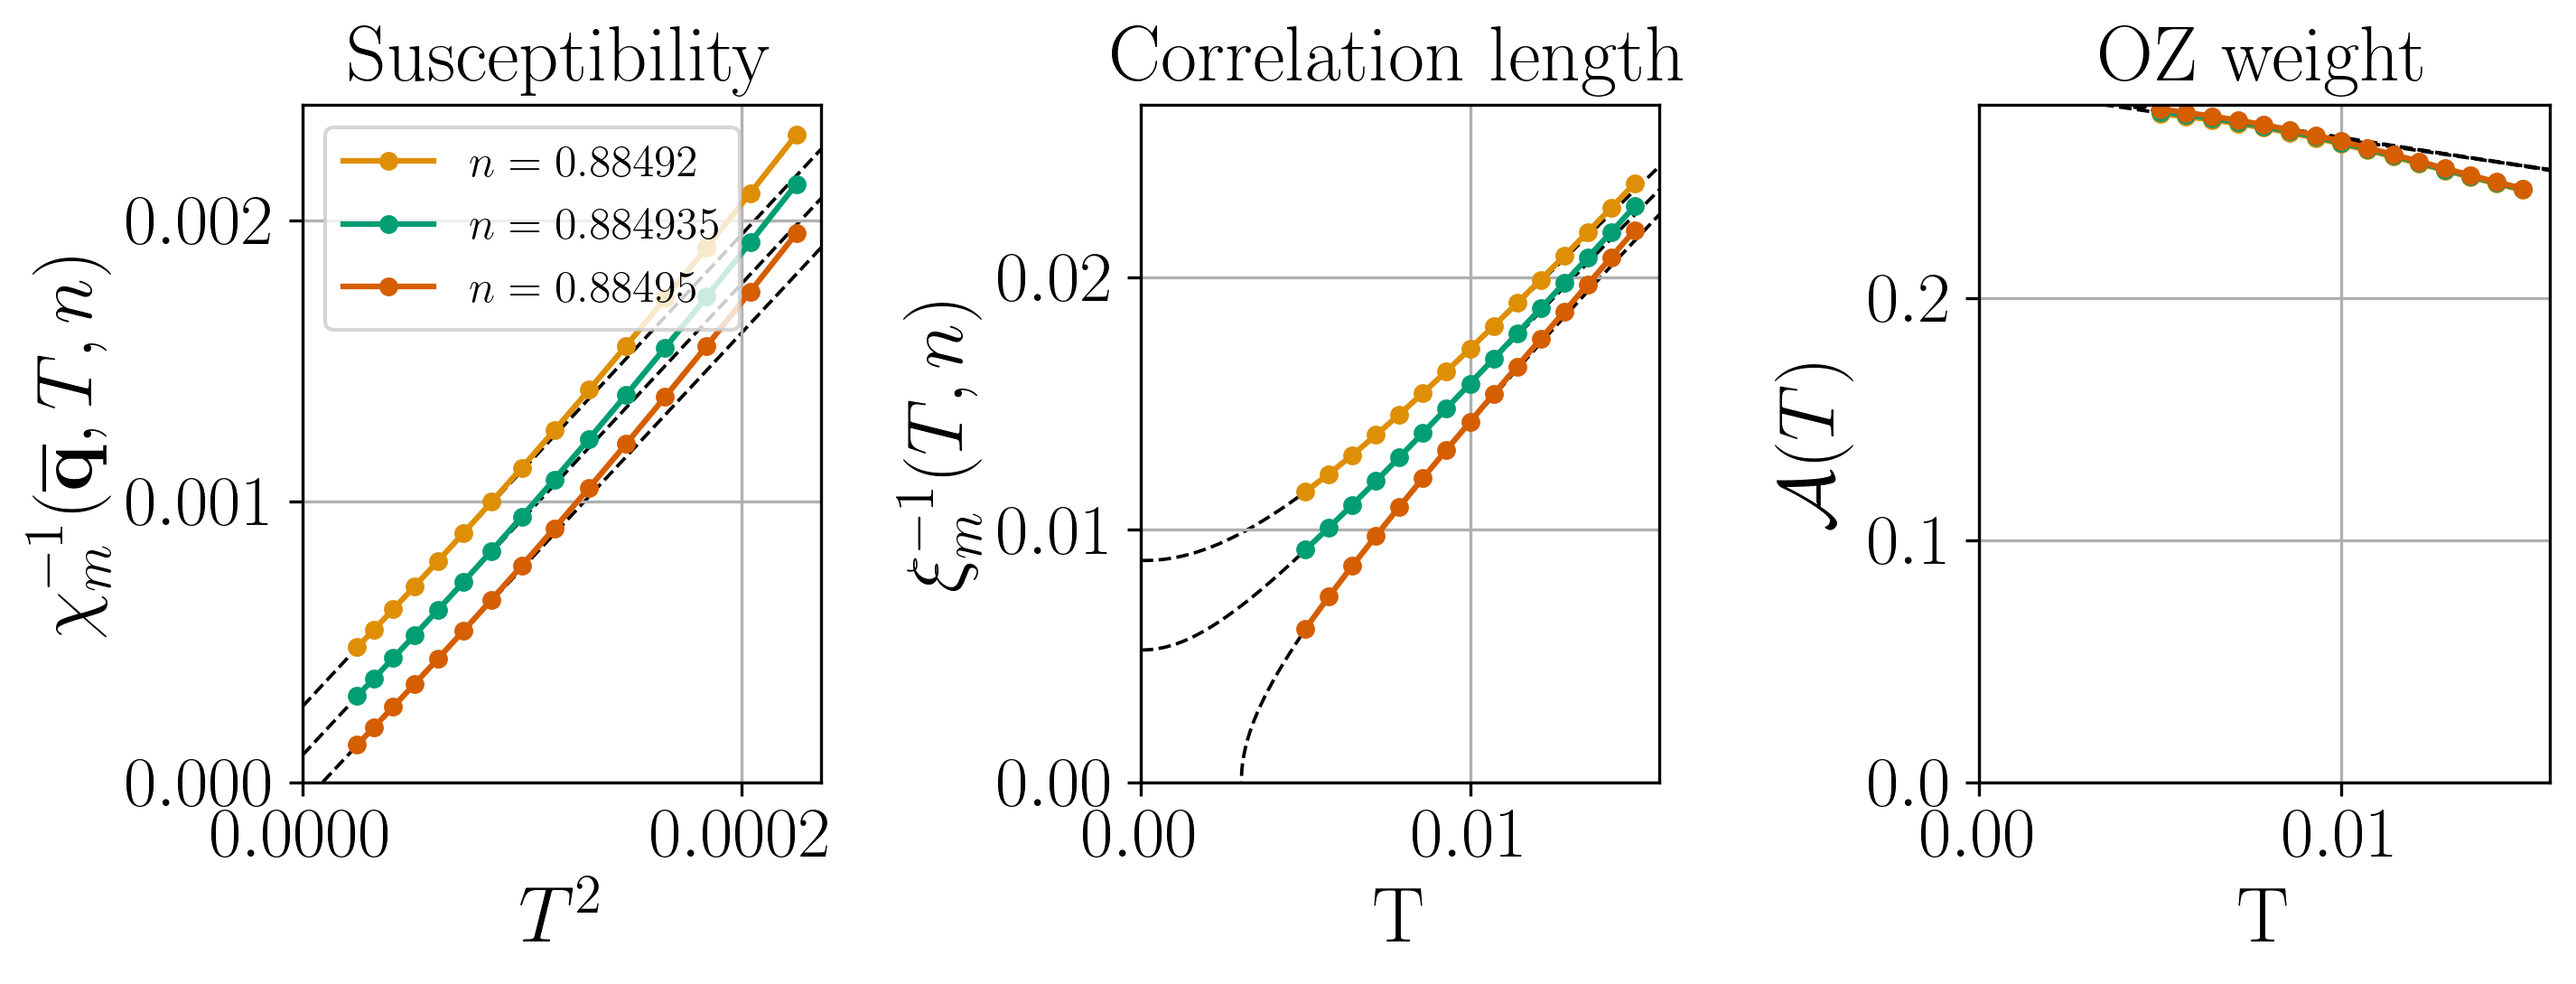

In [4]:
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

data['n'] = data['n'][1:-1]
for k in ['invchi_min', 'invxi_min', 'OZ_weight']:
    data[k] = data[k][1:-1,:]
    
plot_scaling(data, x_exp=(2, 1, 1), fit=True, right='OZ', figsize=(10, 4), c0=1, bigger_labels=3)
plt.show()

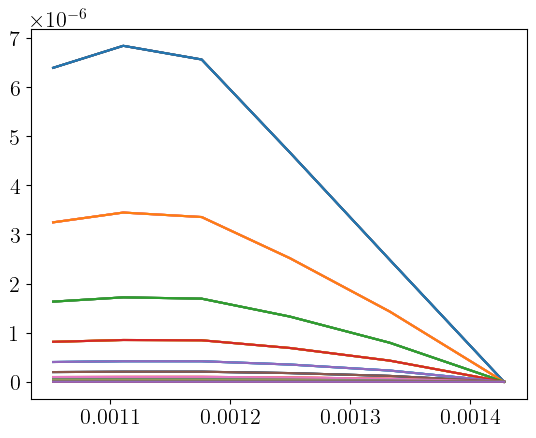

In [4]:
U = 3
tp = 0.2

data_list = []
nk_list = np.arange(700, 1000, 50)
for nk in nk_list:
    with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}nk{nk}.h5", "r") as ar:
        data = {k: ar[k] for k in ar}
    data_list.append(data)

for n in range(5):
    invchi_min = np.array([data['invchi_min'][0,:] for data in data_list])

    plt.plot(1/nk_list, invchi_min - invchi_min[0])
plt.show()

/home/carlo/Desktop/qc/scripts/plot.py:457: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


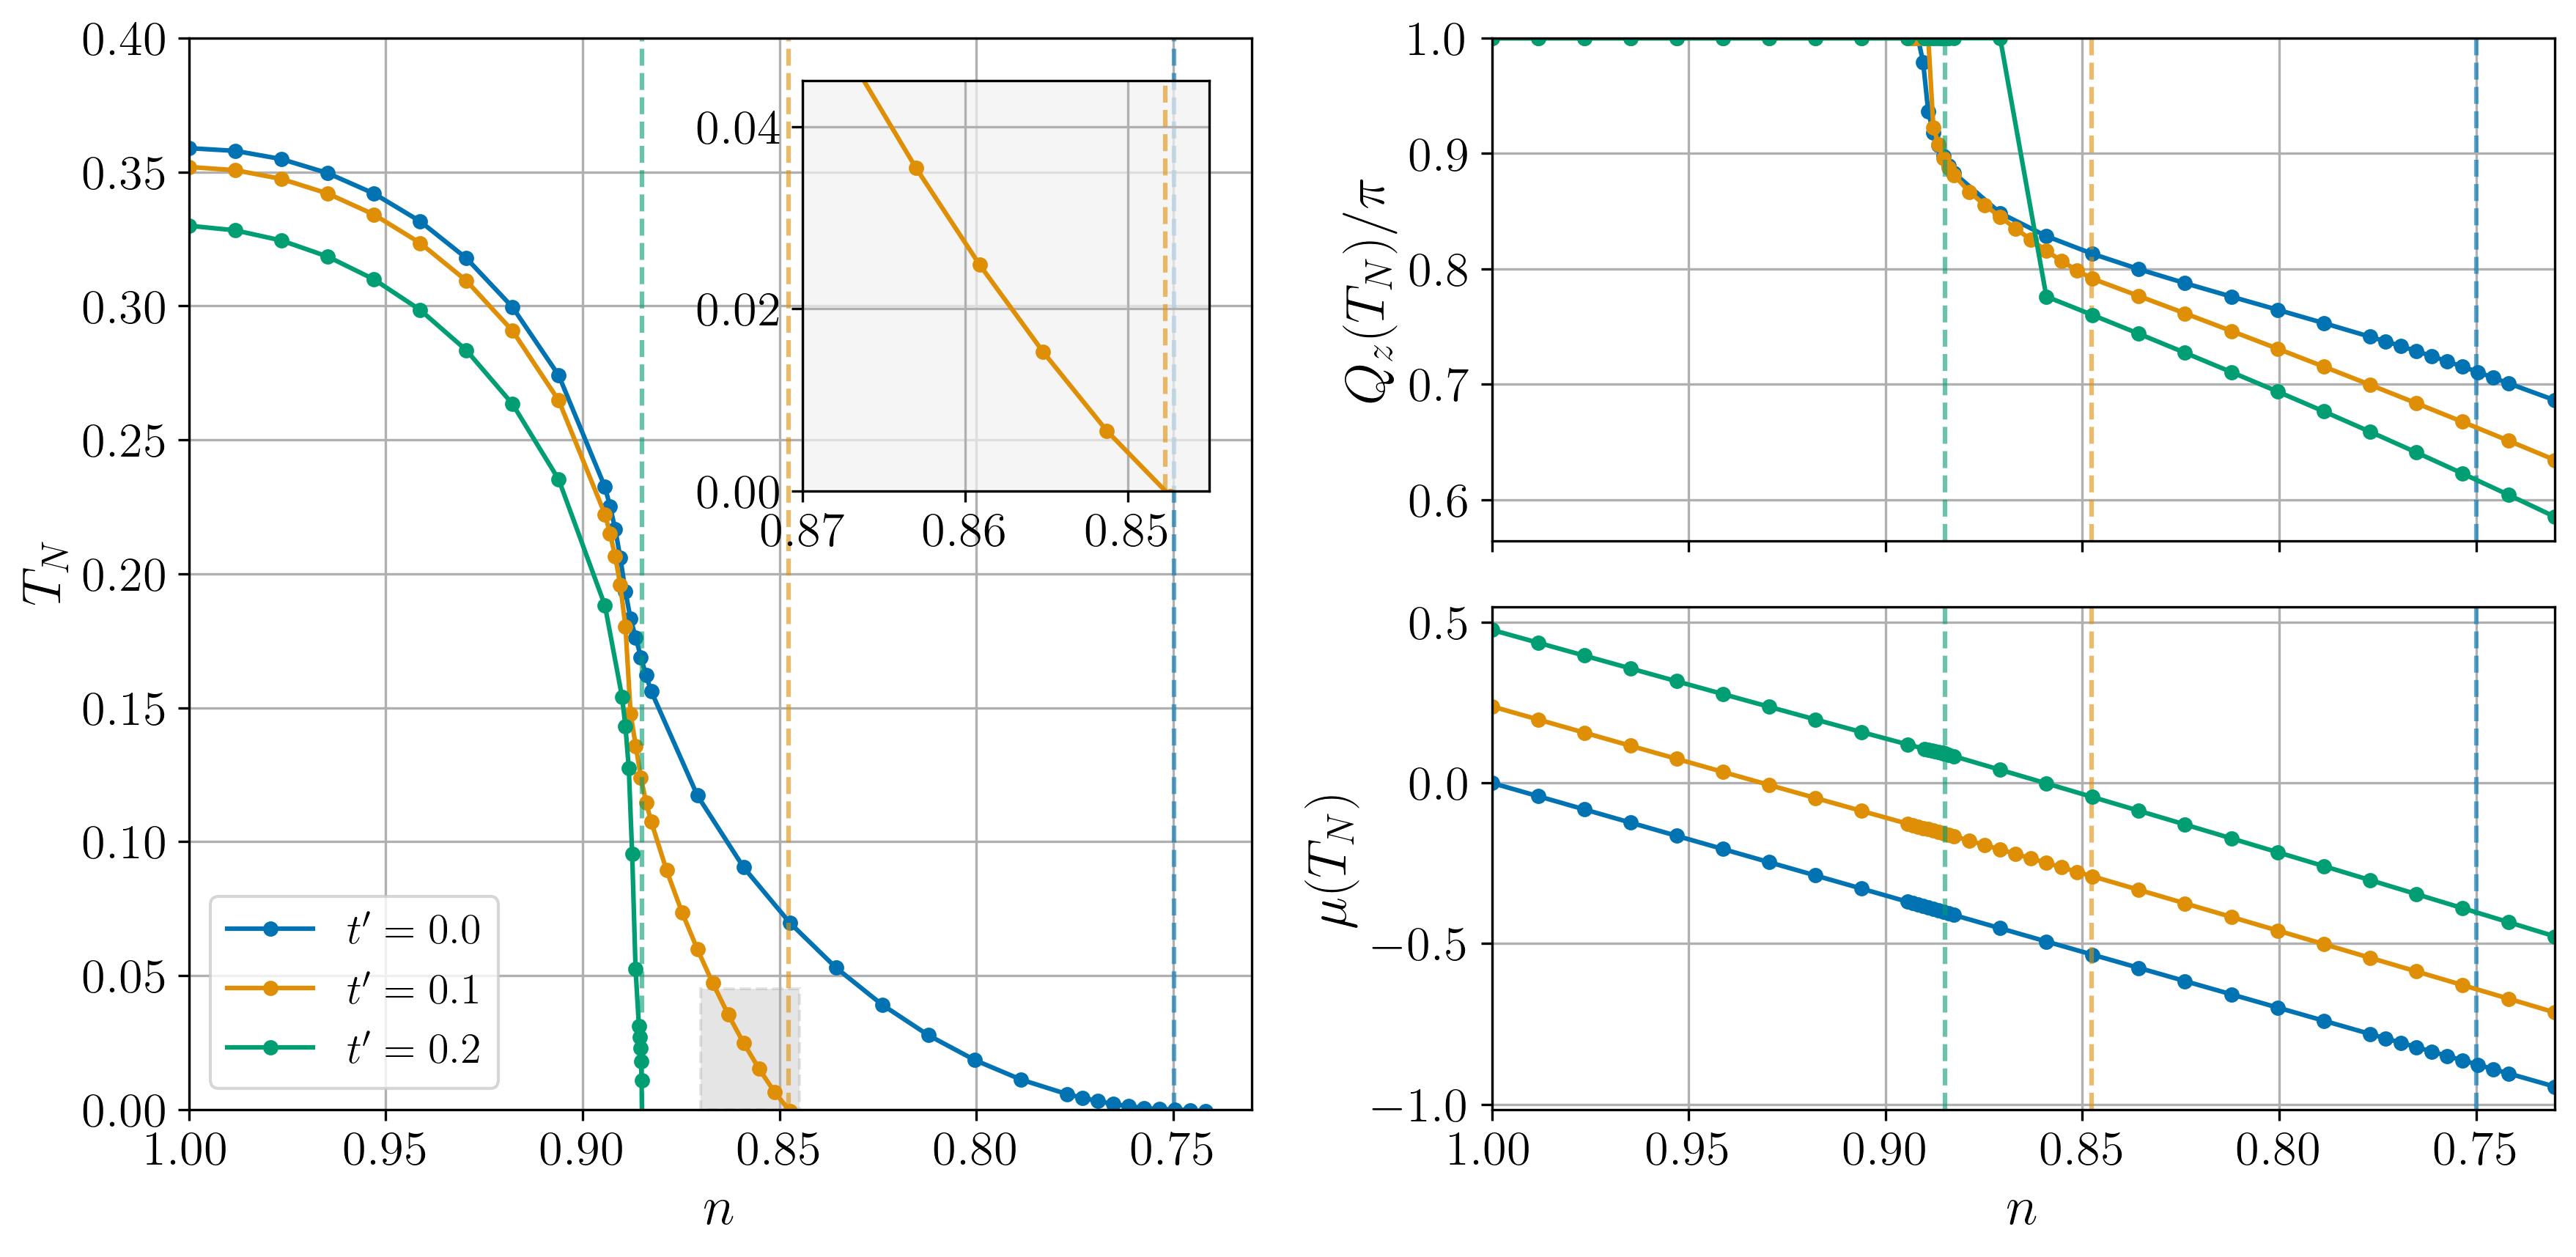

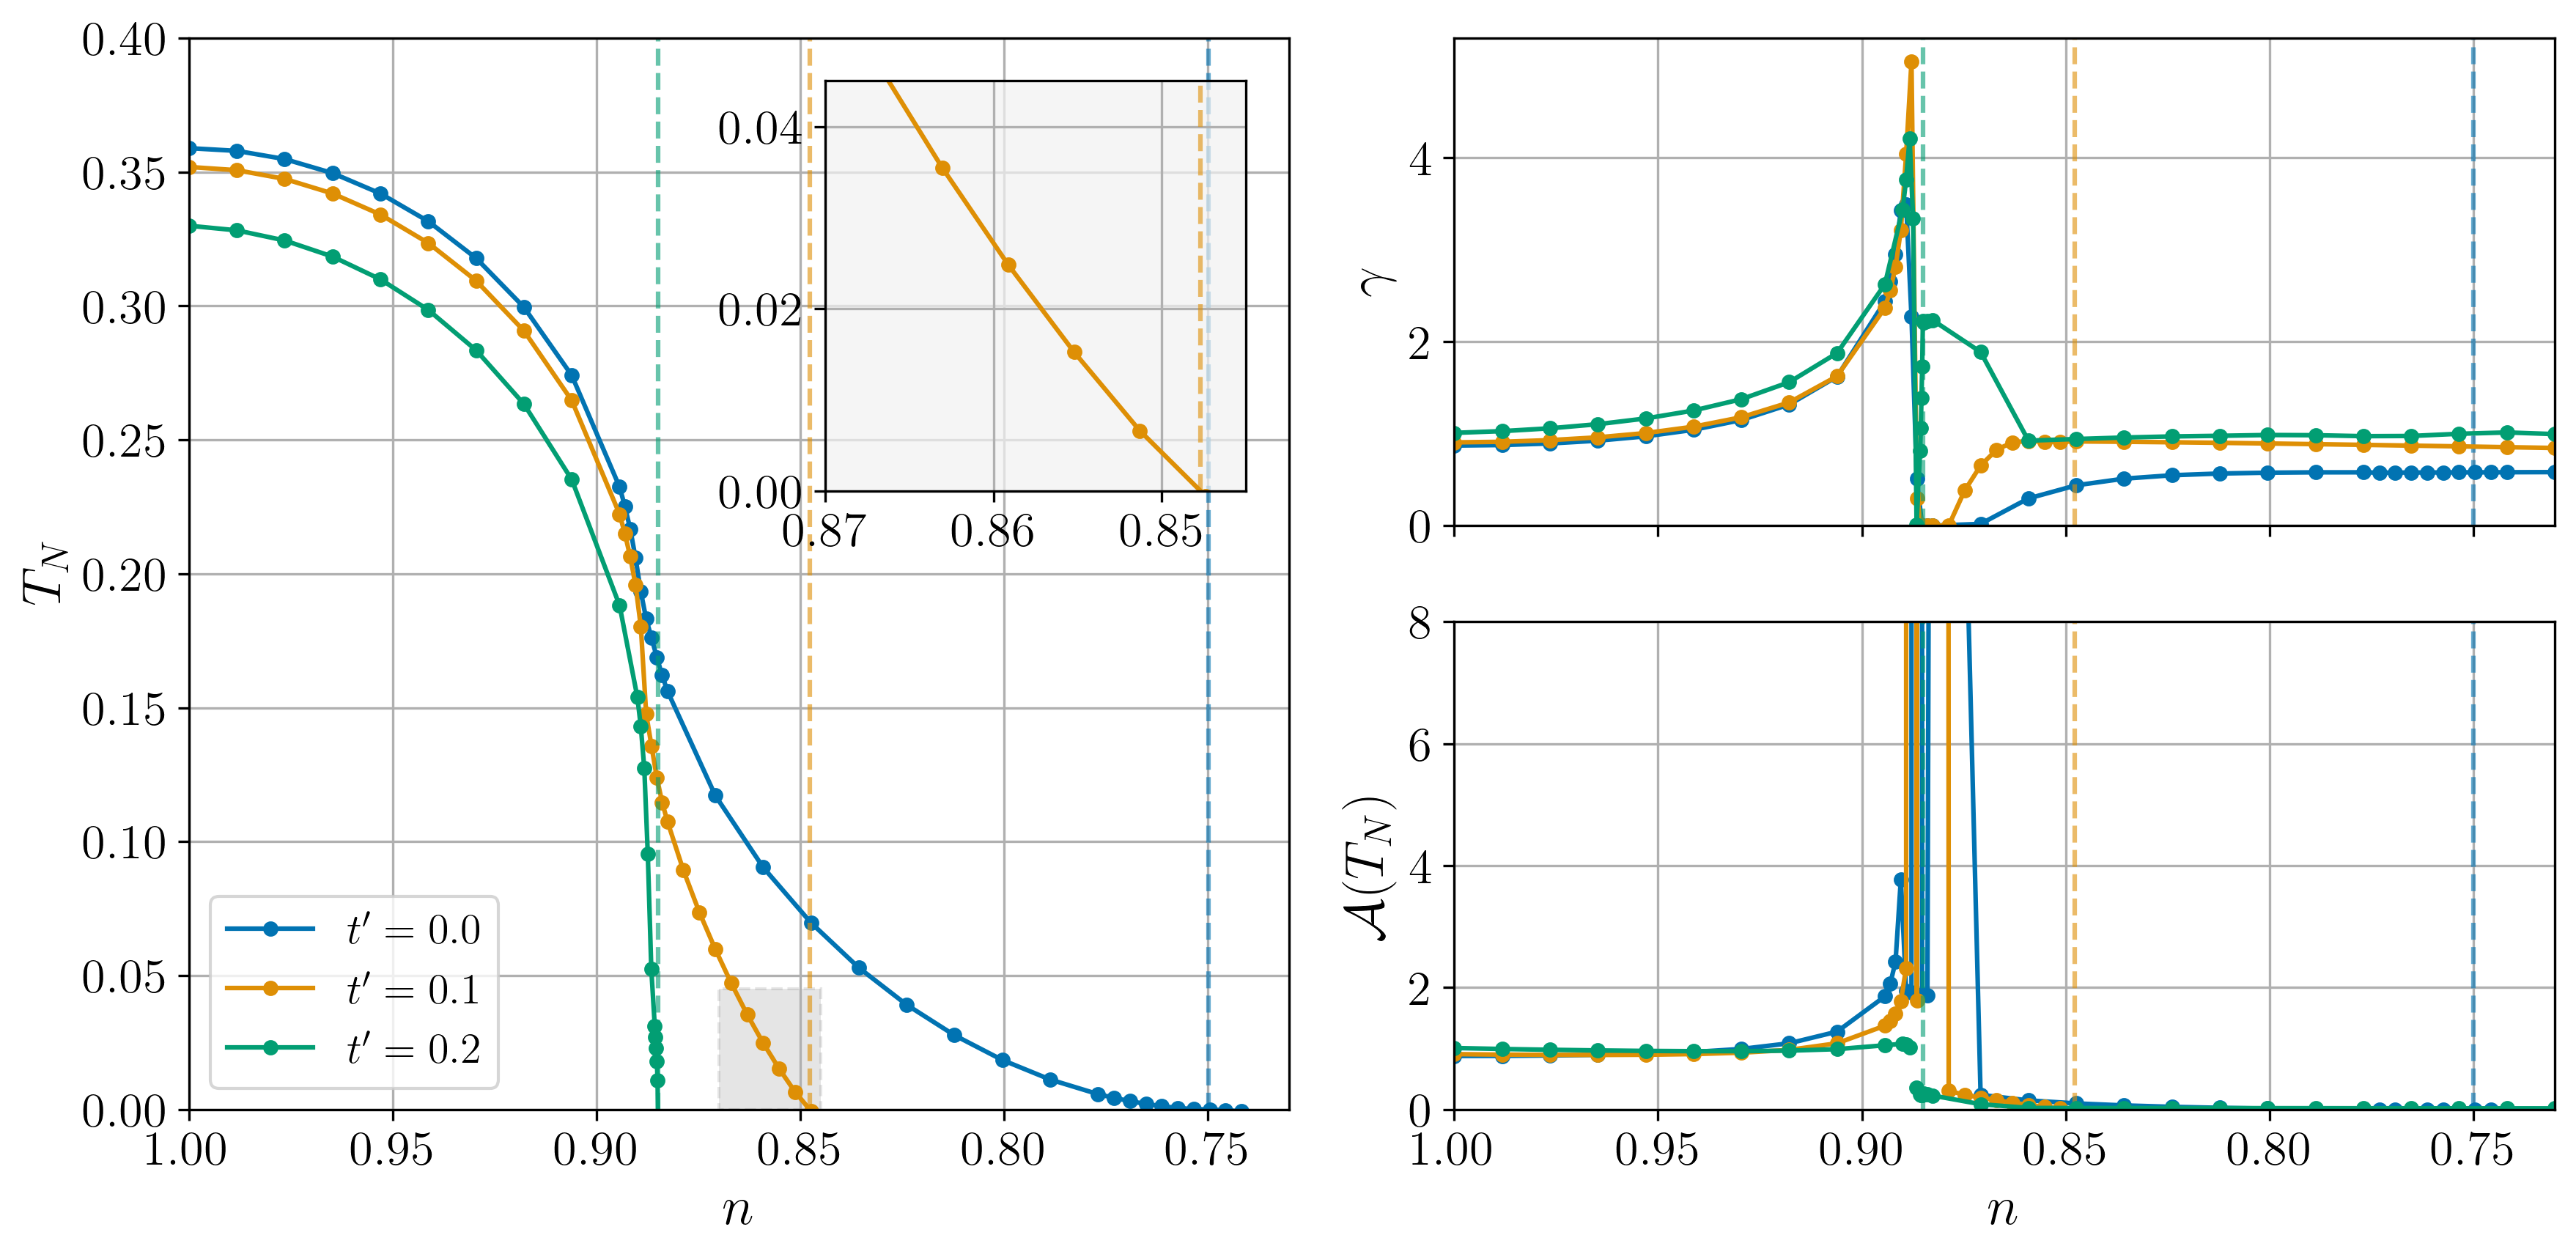

In [33]:
U = 3
tp_list = [0., 0.1, 0.2]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

fig1 = plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.845, 0.87], inset_yrange=[0, 0.045], subplots='commens')
plt.show()
plt.close(fig1)

fig2 = plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.845, 0.87], inset_yrange=[0, 0.045], subplots='scaling')
plt.show()
plt.close(fig2)

/home/carlo/Desktop/qc/scripts/plot.py:453: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


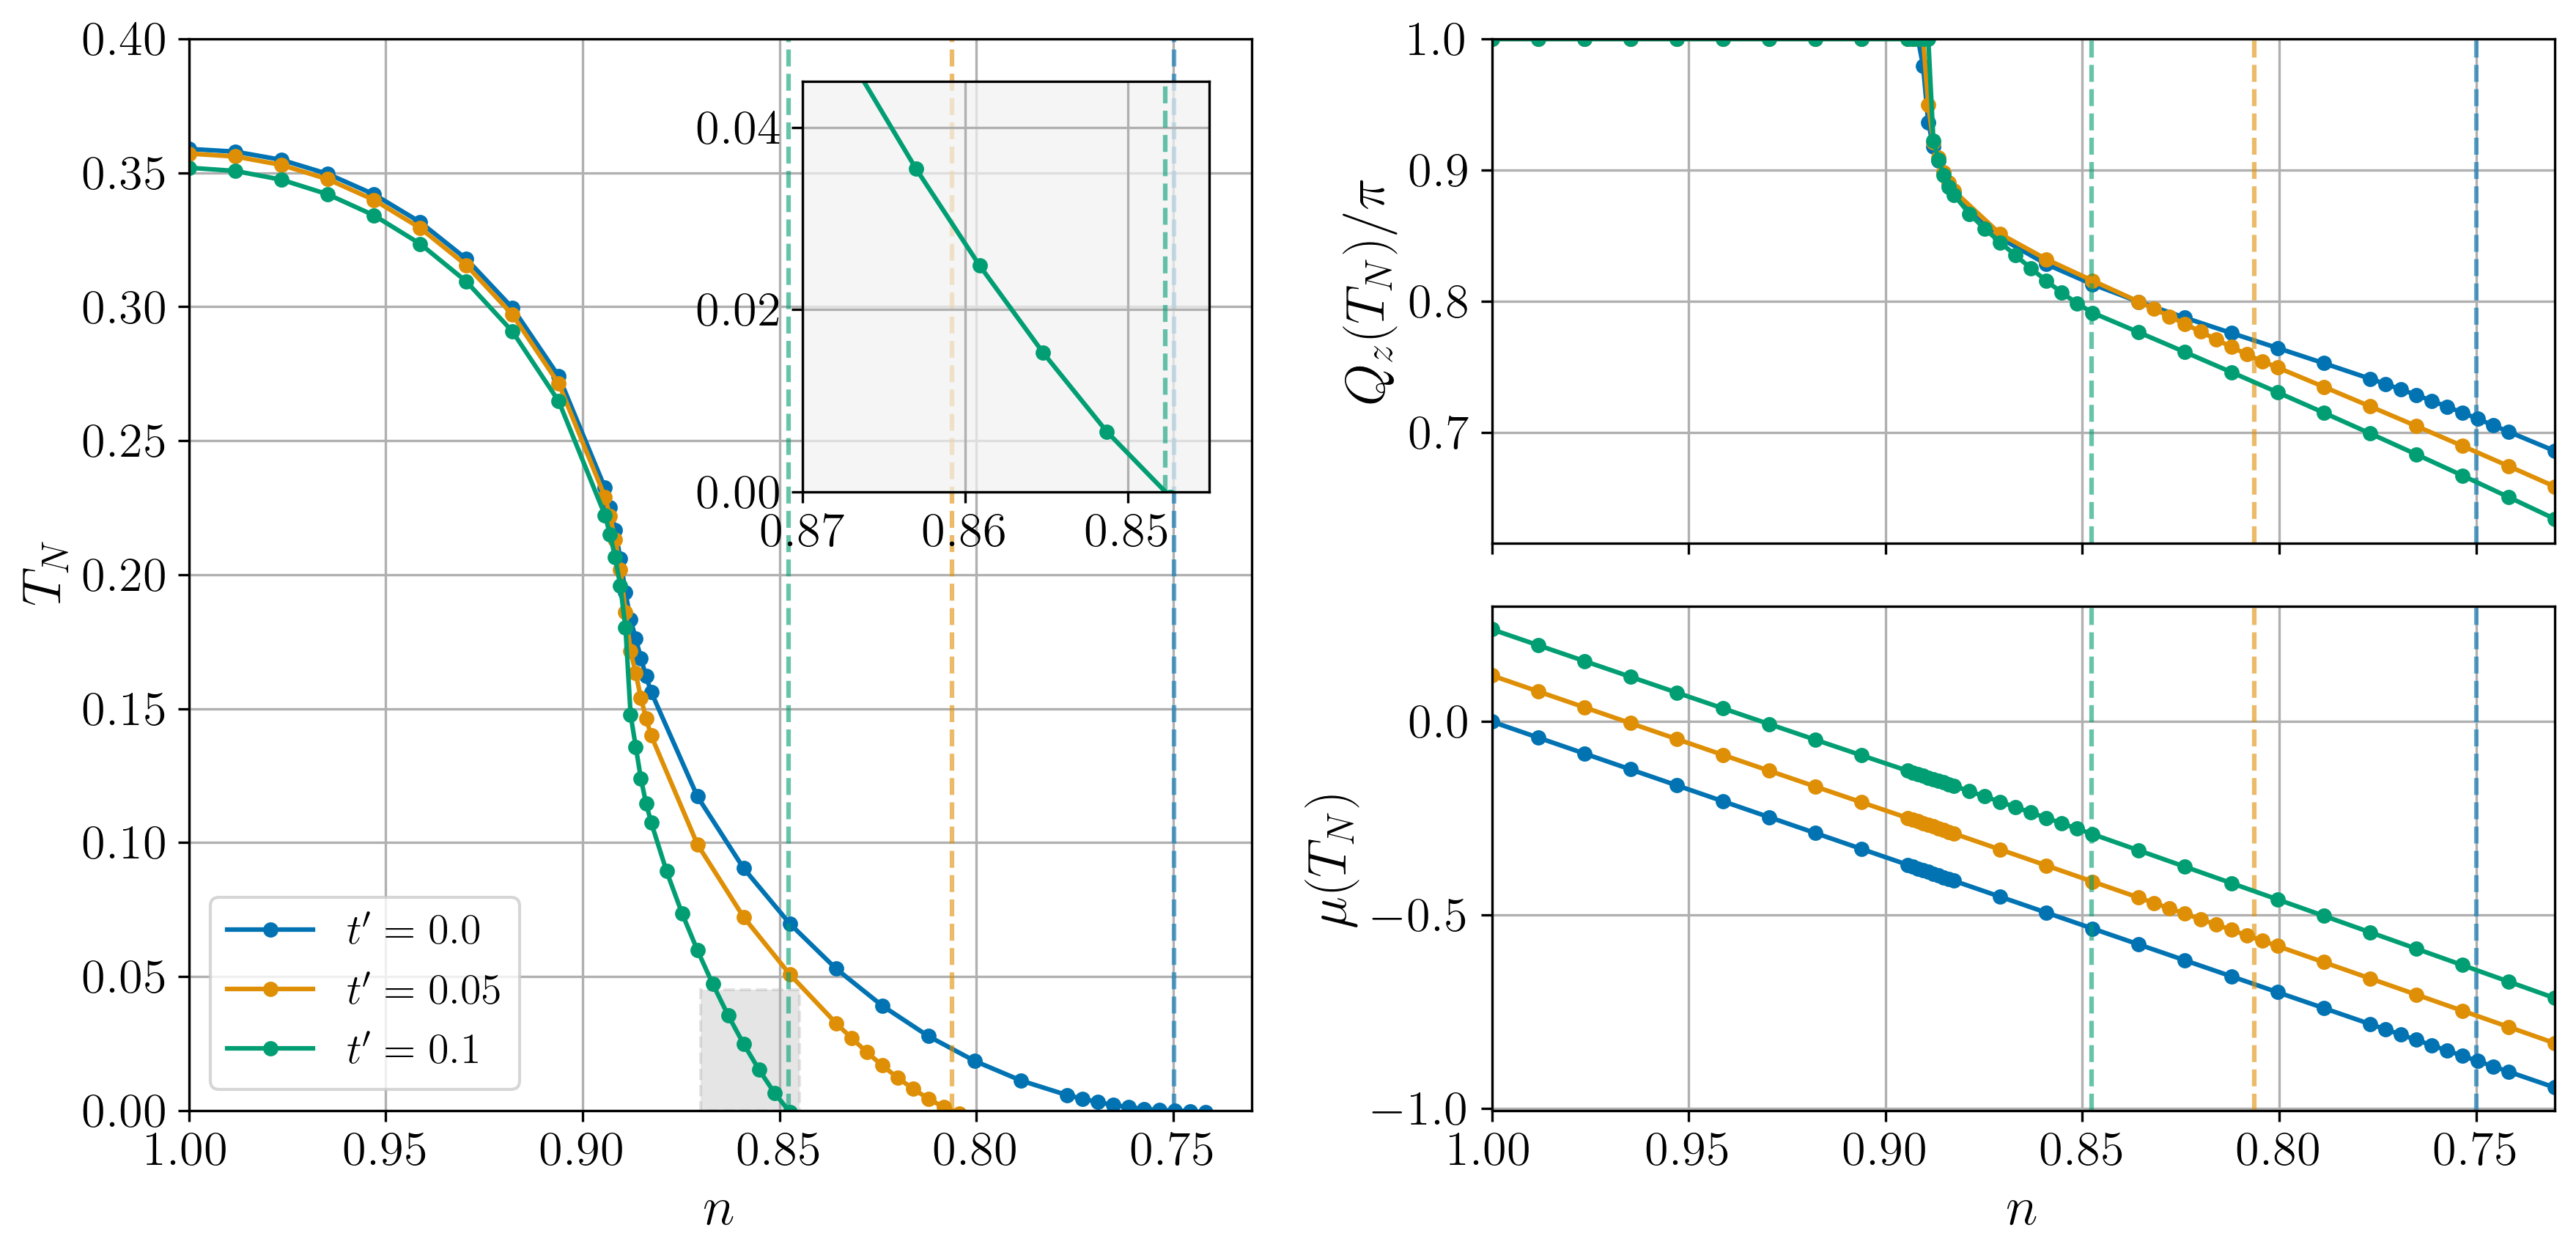

/home/carlo/Desktop/qc/scripts/plot.py:453: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


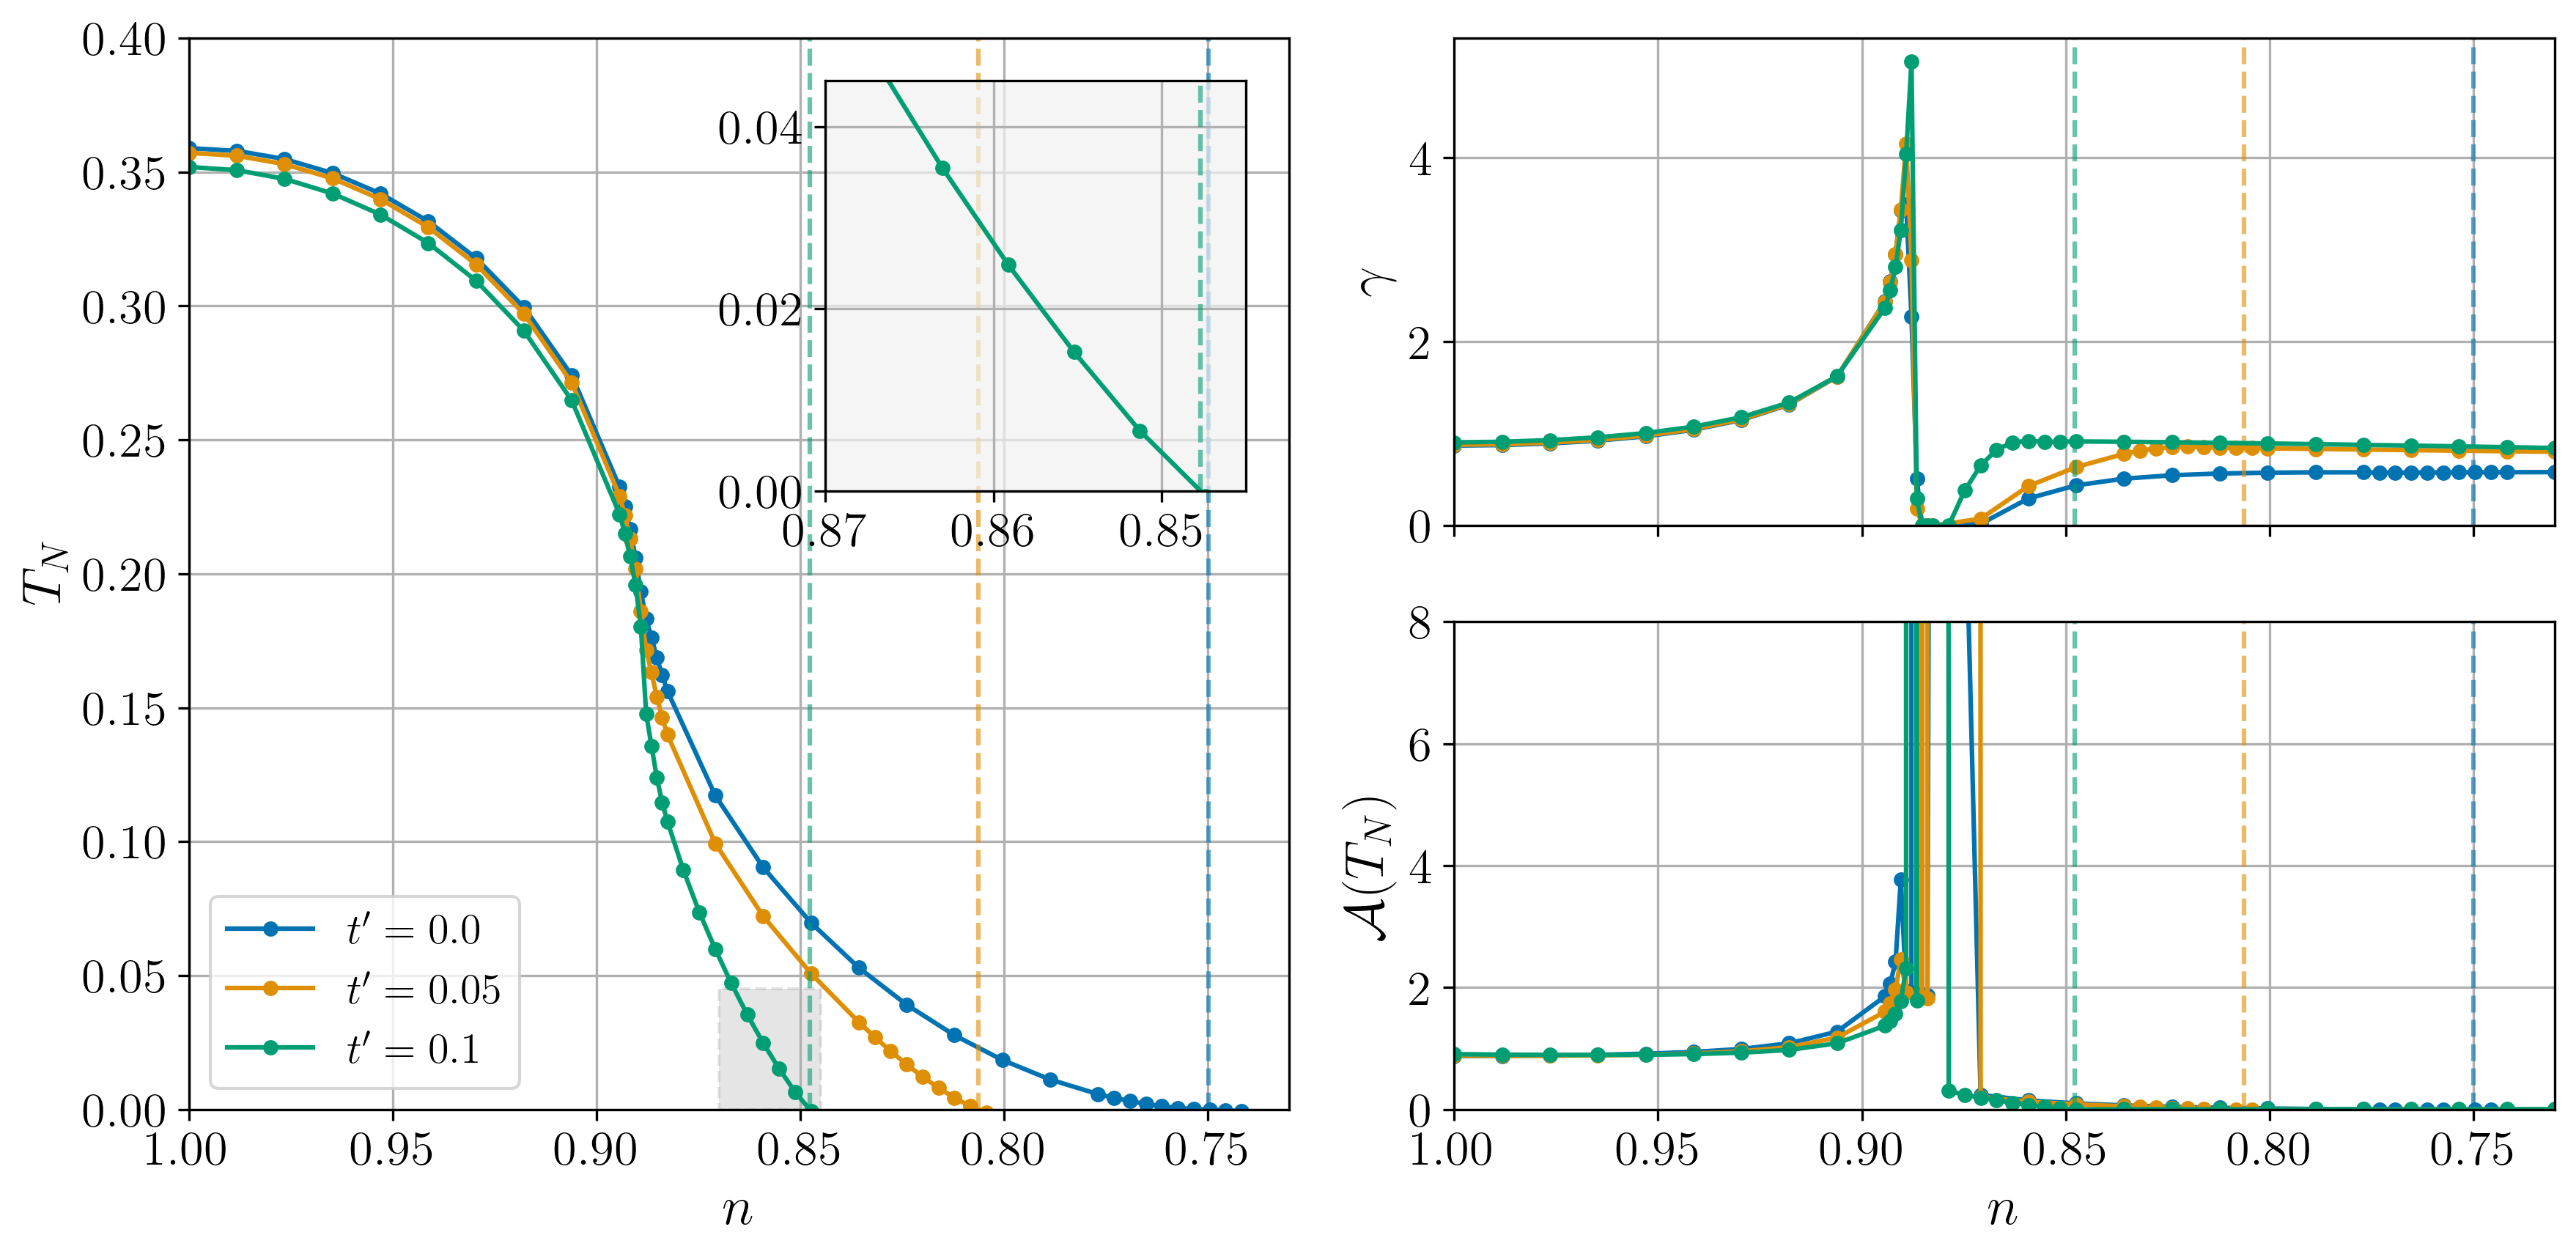

In [ ]:
U = 3
tp_list = [0., 0.05, 0.1]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

fig1 = plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.845, 0.87], inset_yrange=[0, 0.045], subplots='commens')
plt.show()
plt.close(fig1)

fig2 = plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.845, 0.87], inset_yrange=[0, 0.045], subplots='scaling')
plt.show()
plt.close(fig2)

In [ ]:

coarse = np.linspace(0.73, 1., 24)
fine = np.linspace(coarse[13], coarse[14], 10)
fine2 = np.linspace(coarse[10], coarse[13], 10)
#finer = np.linspace(coarse[10], coarse[12], 5)
#finer2 = np.linspace(coarse[12], coarse[13], 6)

coarse = coarse[((coarse < fine[0]) | (coarse > fine[-1])) & ((coarse < fine2[0]) | (coarse > fine2[-1]))]
#fine = fine[(fine < finer[0]) | (fine > finer[-1])]
#fine = fine[((fine < finer[0]) | (fine > finer[-1])) & ((fine < finer2[0]) | (fine > finer2[-1]))]

n_list = np.unique(np.concatenate([coarse, fine, fine2]))
T_list = np.linspace(0., 0.05, 50)

file_name = f'G0tp0U3.h5'
if os.path.exists(f'data/diagram/{file_name}'):
    with HDFArchive(f'data/diagram/{file_name}', "r") as ar:
        if ar['fit'] is True:
            old_n = ar['n']

            Tc = - abs(ar['c']/ar['a'])**(1/ar['b']) * np.sign(ar['c']/ar['a'])

            # Fill NaNs by linear interpolation
            mask = np.isnan(Tc)
            Tc[mask] = np.interp(old_n[mask], old_n[~mask], Tc[~mask])

            old_Tc = np.interp(n_list, old_n, Tc)
        else:
            old_Tc = np.zeros(len(n_list))
        print(old_Tc)
else:
    old_Tc = np.zeros(len(n_list))

new_T_list = T_list[0, np.newaxis] * np.sqrt(np.maximum(old_Tc[np.newaxis, :], 0.005))/np.sqrt(0.005) + np.maximum(old_Tc[np.newaxis, :], 0.005)

par_list = [[{'U': U, 'n': n_list[i], 'T': T} for T in new_T_list[i]] for i in range(len(n_list))]

In [5]:
plt.ioff()

anim1 = create_inset_transition(data_list, tp_list, "t'", 
                                range_start=(0.845, 0.87), range_end=(0.805, 0.83), 
                                yrange_start=(0, 0.045), yrange_end=(0, 0.02))
anim1.save("images/diagramtplowG0_first.mp4", writer="ffmpeg", fps=30)
plt.close(anim1._fig)

anim2 = create_inset_transition(data_list, tp_list, "t'", 
                                range_start=(0.805, 0.83), range_end=(0.745, 0.775), 
                                yrange_start=(0, 0.02), yrange_end=(0, 0.005))
anim2.save("images/diagramtplowG0_second.mp4", writer="ffmpeg", fps=30)
plt.close(anim2._fig)

plt.ion();

/home/carlo/Desktop/qc/scripts/plot.py:453: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


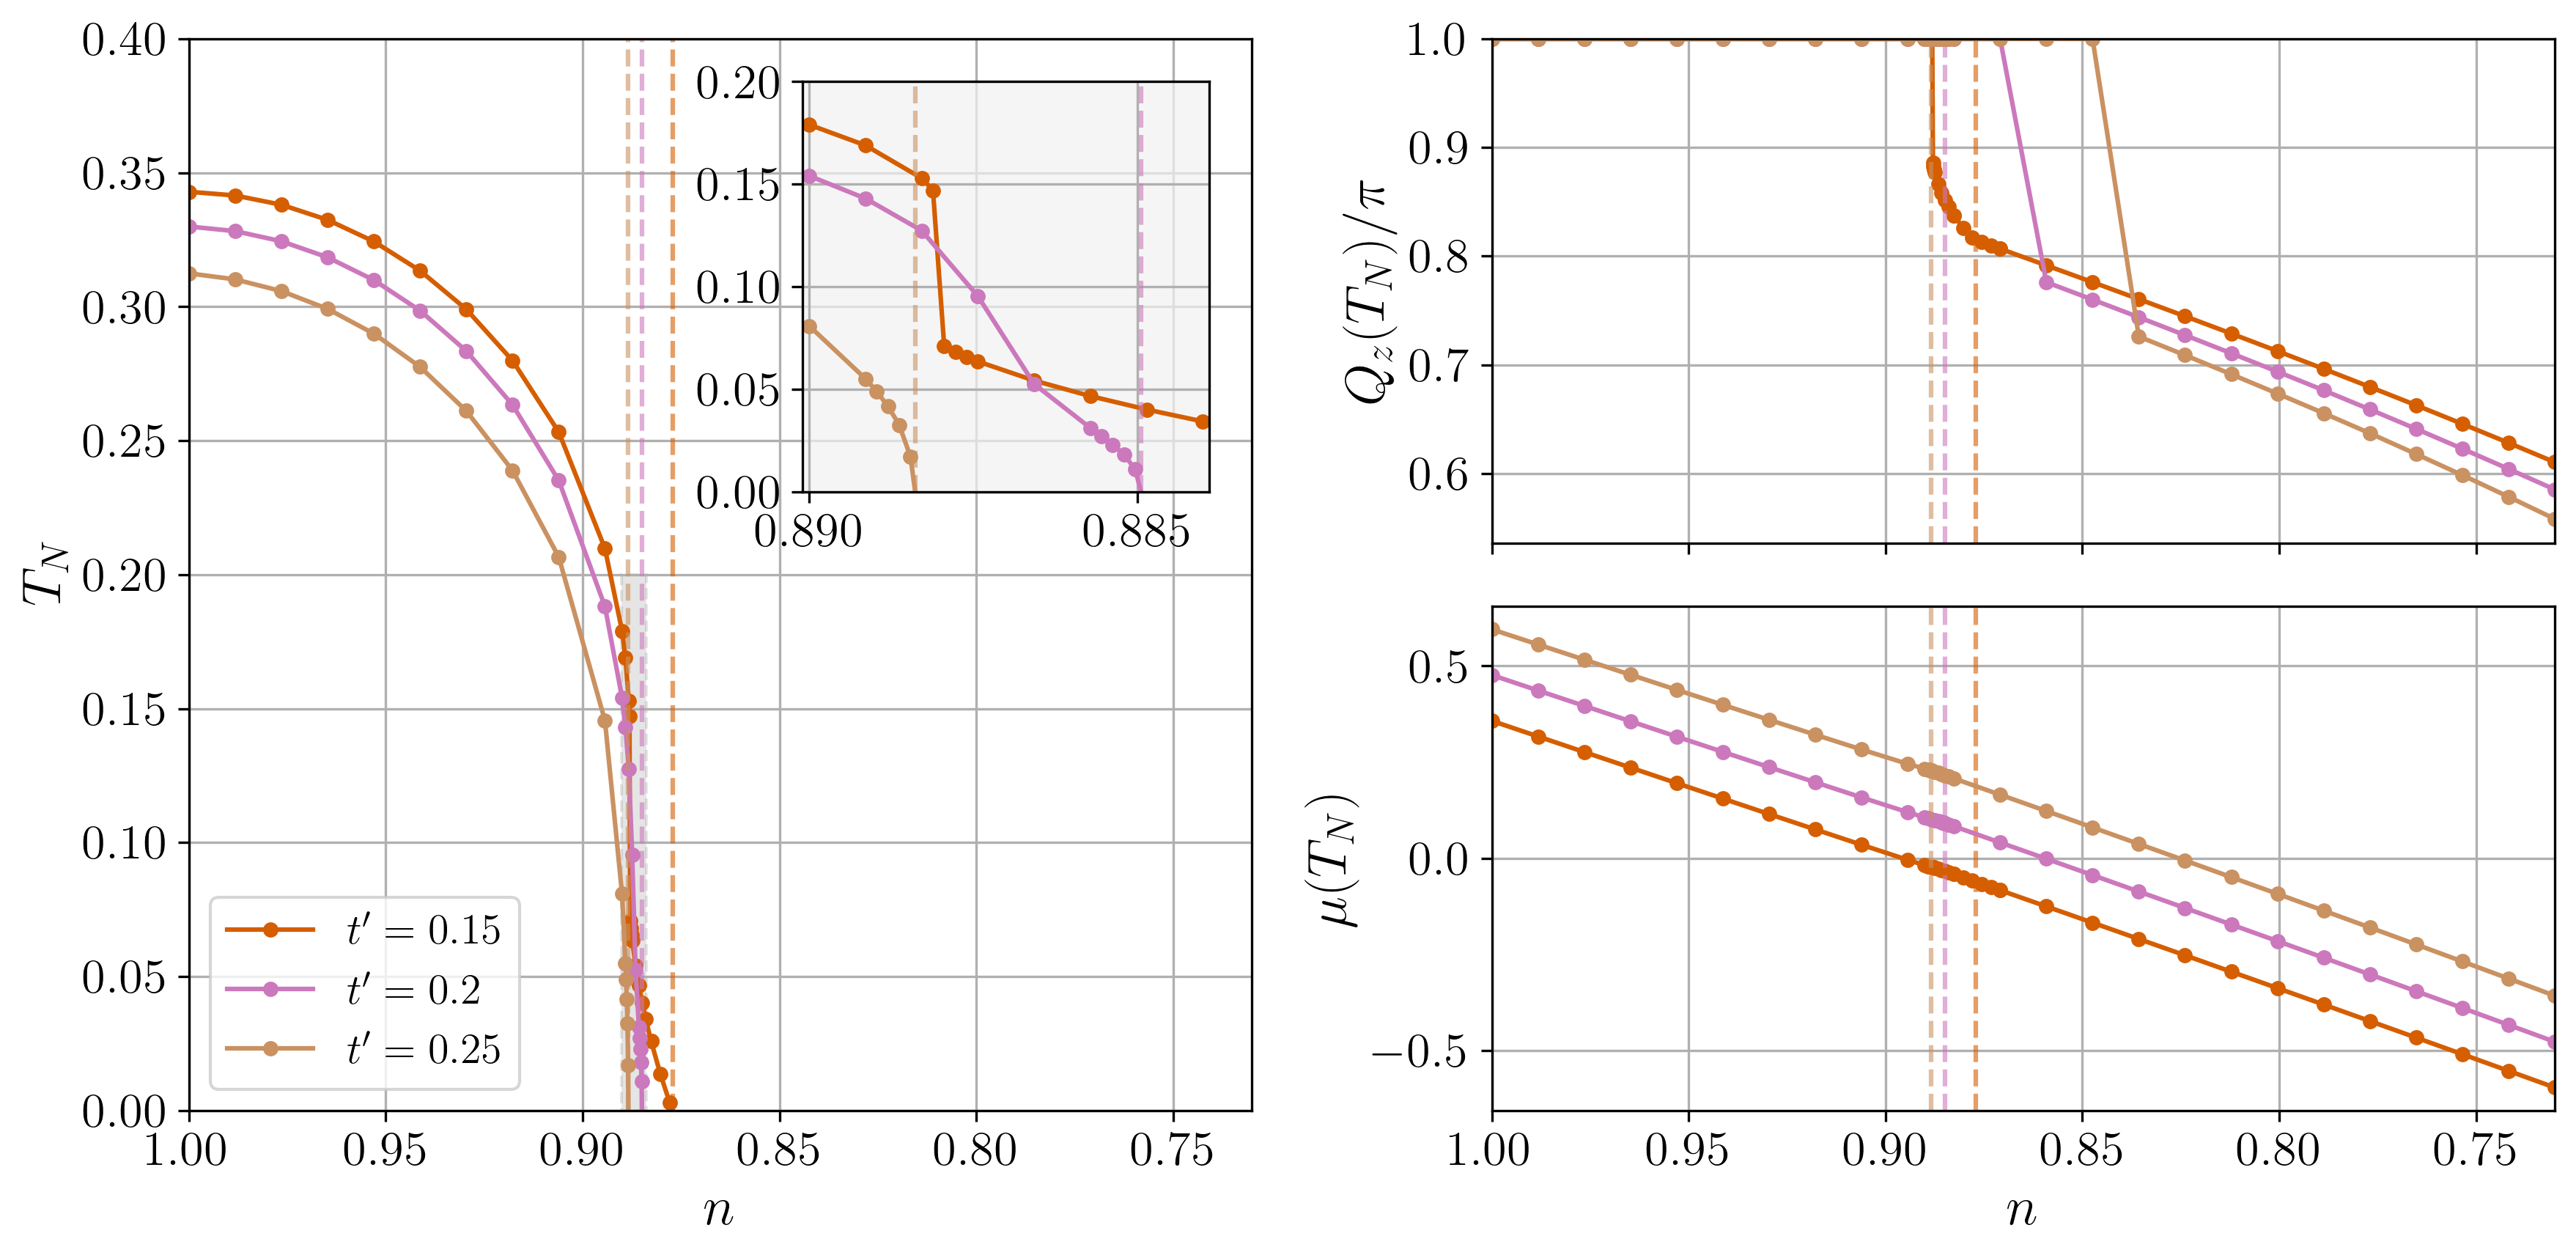

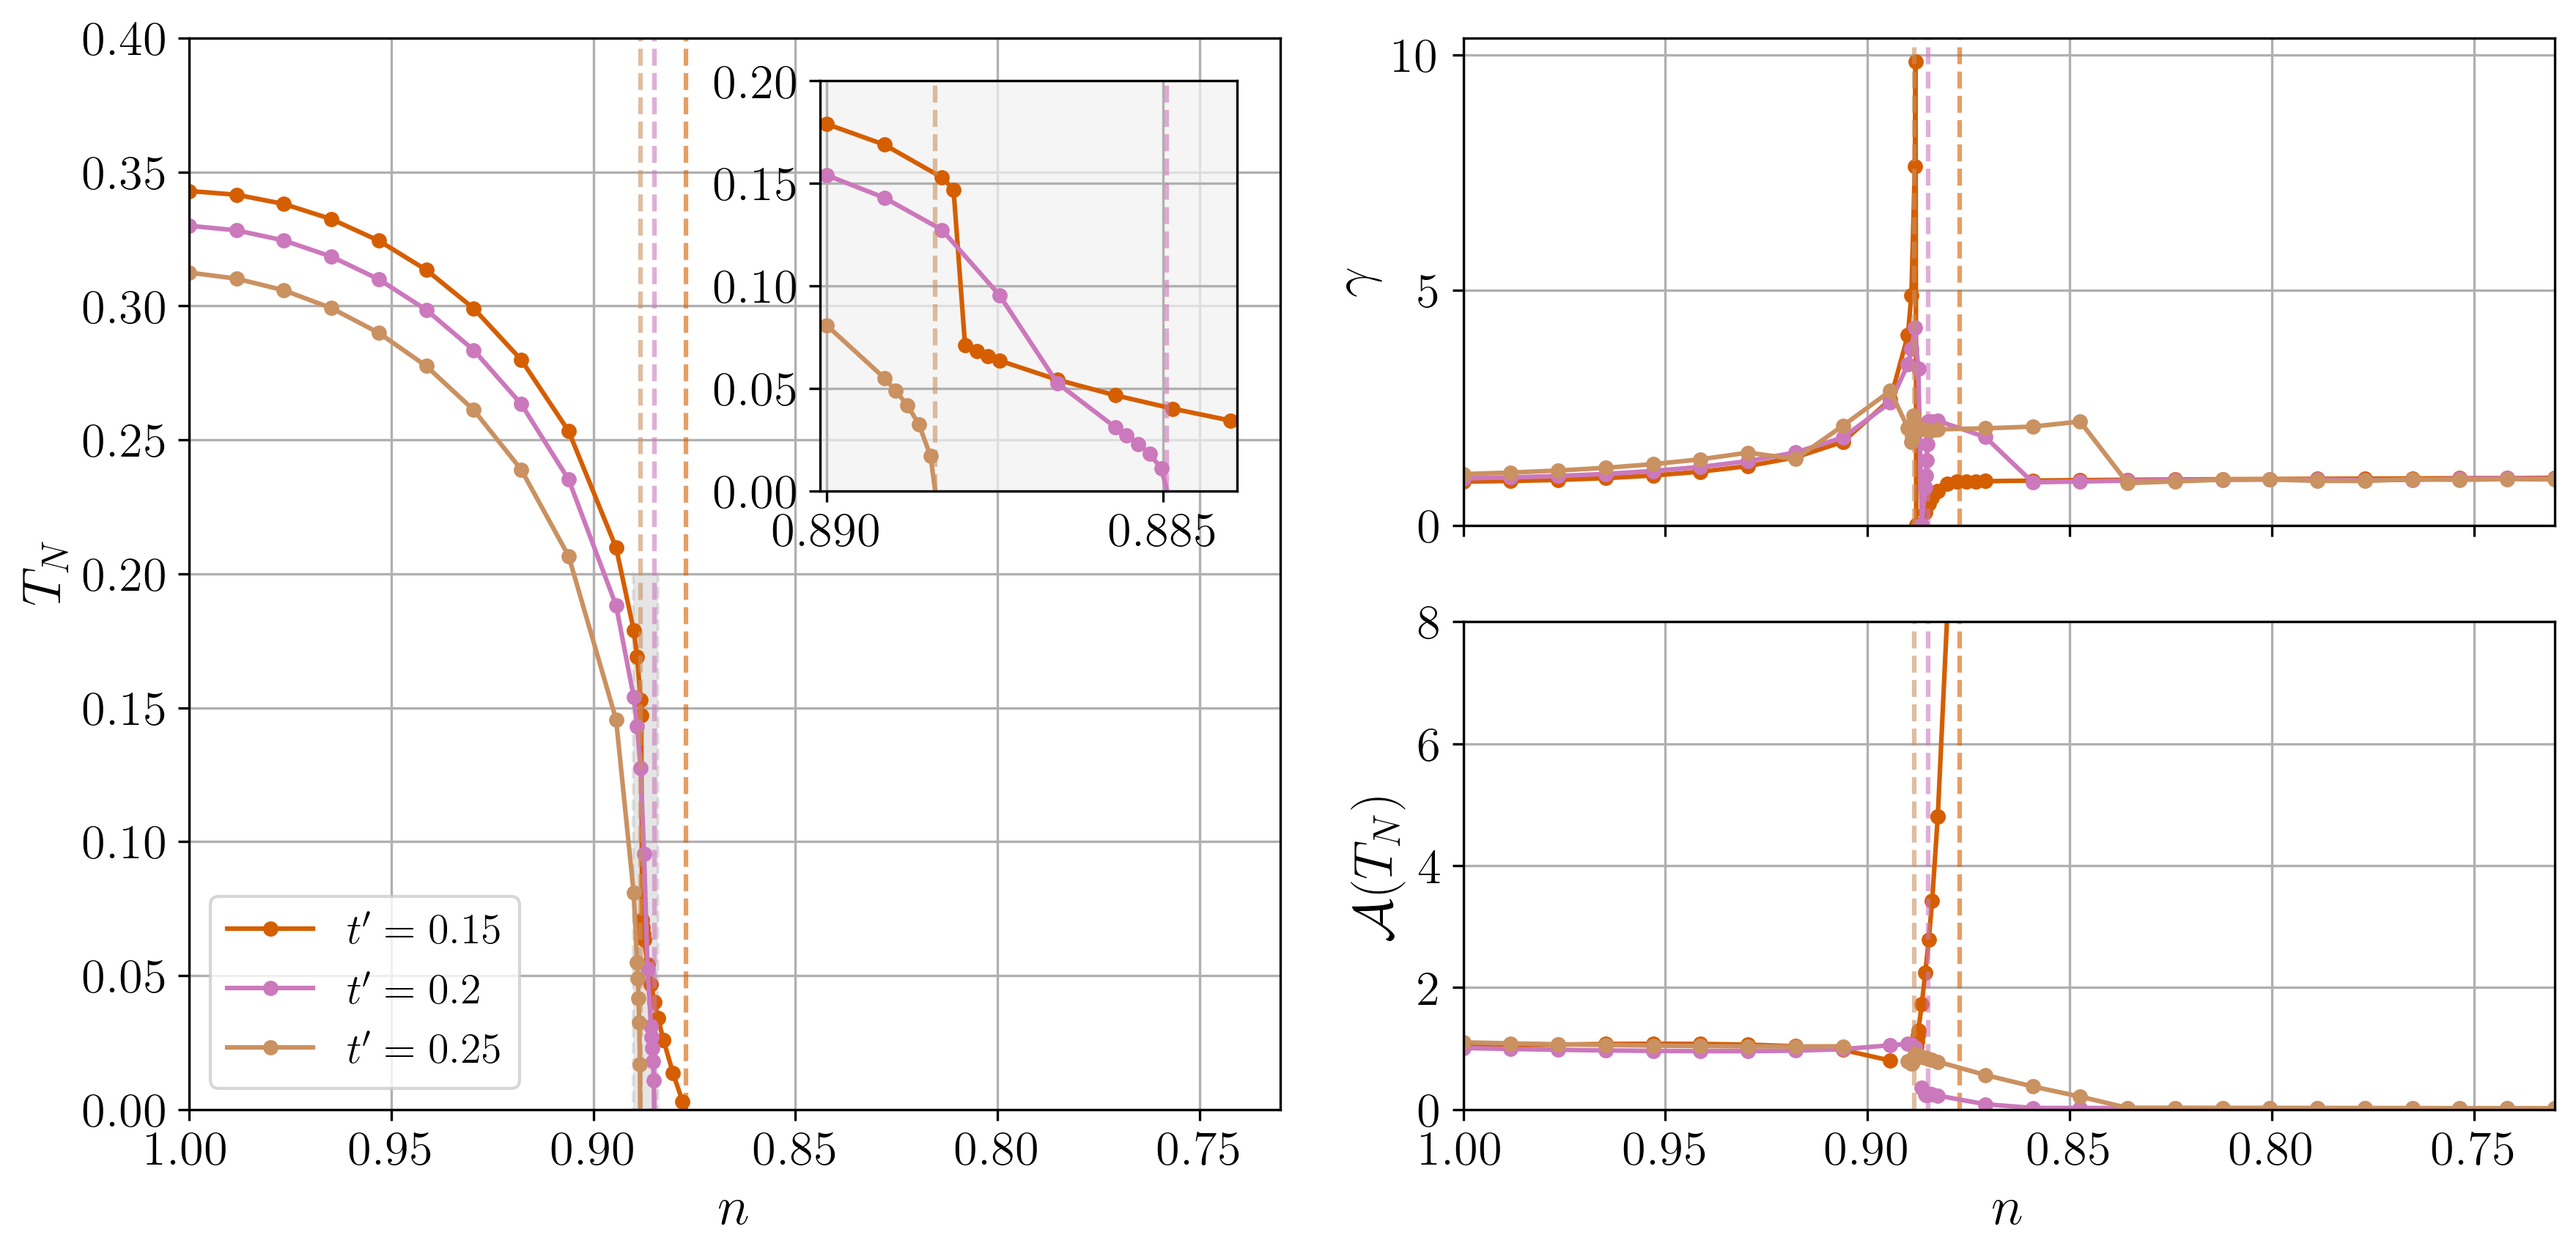

In [3]:
U = 3
tp_list = [0.15, 0.2, 0.25]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

fig1 = plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], inset_yrange=[0, 0.2], subplots='commens', c0=3)
plt.show()
plt.close(fig1)

fig2 = plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], inset_yrange=[0, 0.2], subplots='scaling', c0=3)
plt.show()
plt.close(fig2)

In [52]:
plt.ioff()

anim1 = create_inset_transition(data_list, tp_list, "t'", 
                                range_start=(0.884, 0.89), range_end=(0.884, 0.89), 
                                yrange_start=(0, 0.2), yrange_end=(0, 0.05), c0=3)
anim1.save("images/diagramtphighG0_first.mp4", writer="ffmpeg", fps=30)
plt.close(anim1._fig)

anim2 = create_inset_transition(data_list, tp_list, "t'", 
                                range_start=(0.884, 0.89), range_end=(0.876, 0.882), 
                                yrange_start=(0, 0.05), yrange_end=(0, 0.05), c0=3)
anim2.save("images/diagramtphighG0_second.mp4", writer="ffmpeg", fps=30)
plt.close(anim2._fig)

plt.ion();

/home/carlo/Desktop/qc/scripts/plot.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  qz_grid_fitted = np.linspace(Qz_fit[i]-data['xi_range'][i][-1], Qz_fit[i]+data['xi_range'][i][-1], 20)


In [ ]:
from numba import njit

@njit
def dos_func(E_vals, e_k, w_k, eta):

    Nk = len(e_k)
    dos = np.zeros(len(E_vals), dtype=np.float64)
    for iE in range(len(E_vals)):
        for k in range(Nk):
            dos[iE] += w_k[k] / ((E_vals[iE] - e_k[k])**2 + eta**2)

    return (eta / np.pi) * dos


12.012012012012013


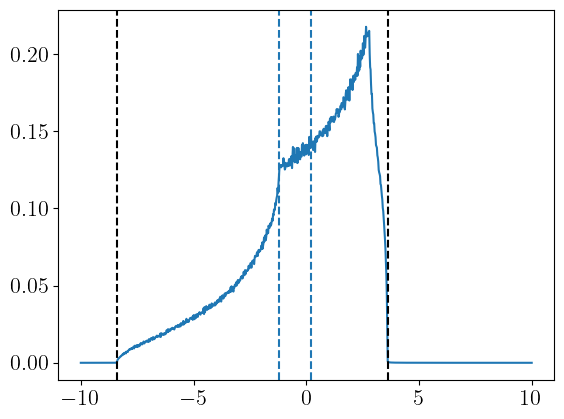

In [41]:
tp = 0.2
lat = LATTICE(tp=tp)
bz = BZ(lat, nk=500)

E_vals = np.linspace(-10, 10, 1000)
eta = 0.001

dos = dos_func(E_vals, bz.e_k, bz.w_k, eta)

plt.plot(E_vals, dos)
plt.axvline(x=tp, linestyle='--')
plt.axvline(x=-2+4*tp, linestyle='--')

finite_dos = np.argwhere(dos > 5e-4)[:,0]
plt.axvline(x=E_vals[finite_dos[-1]], linestyle='--', color='black')
plt.axvline(x=E_vals[finite_dos[0]], linestyle='--', color='black')
#plt.yscale('log')

bandwidth = E_vals[finite_dos[-1]] - E_vals[finite_dos[0]]
print(bandwidth)

In [ ]:
tp = 0.
lat = LATTICE(tp=tp)
bz = BZ(lat, nk=500)

n = 0.745
T = np.linspace(0.005, 0.015, 15)

mu = get_mu(e_k=bz.e_k, n_goal=0.9, beta=1/0.1)

plt.plot(E_vals, dos)
plt.axvline(x=tp, linestyle='--')
plt.axvline(x=-2+4*tp, linestyle='--')

finite_dos = np.argwhere(dos > 5e-4)[:,0]
plt.axvline(x=E_vals[finite_dos[-1]], linestyle='--', color='black')
plt.axvline(x=E_vals[finite_dos[0]], linestyle='--', color='black')
#plt.yscale('log')

bandwidth = E_vals[finite_dos[-1]] - E_vals[finite_dos[0]]
print(bandwidth)